# Feature analysis — `trade_rate_surge`

This notebook follows the project's feature-analysis **method** (the current cross-venue-gap template,
sibling to `mid_rate_surge`) on a new feature: **`trade_rate_surge`** — a fast/slow ratio of a venue's
**trade rate** (trades per second). The text says what to do and why; the code does it.

We build features for a model that forecasts one exchange's mid-price about 100 ms ahead. Three
crypto exchanges appear throughout — **byb** (Bybit), **bin** (Binance), **okx** (OKX) — and
**byb is the target**: the one we predict. ("Mid-price" = the midpoint between the best buy and
best sell quote.) The next section recaps the model these features feed.

**The feature, in one line.** A venue's **trade rate** is how often *that venue* prints a trade, per
second. Smooth that rate two ways — a **fast** EMA and a **slow** EMA — and take the ratio:

`trade_rate_surge(ex; fast, slow) = trade_rate(ex, fast) / trade_rate(ex, slow)`

A ratio above 1 means that venue is trading *faster than its own baseline* right now — a trade-tempo
**surge**; below 1, a lull. The hypothesis is that a surge **predicts intensity**: when a venue starts
trading quickly, more byb mid-moves are about to follow. This reuses the **same `trade_rate(N)` raw atom**
as `trade_rate_normalised` (venue trades/sec, EMA span `N`) — here as a dimensionless fast/slow ratio, so
**no yardstick division is needed**.

**This is a per-exchange feature (like the template's dislocation gap).** Exactly as the template's gap
feature computes a value for *each* non-byb venue, and `mid_rate_surge` a surge for each venue, we compute a
trade-rate surge for **each** venue — byb, okx **and** bin — each from that venue's OWN trades, and ask
whether it predicts **byb's** next move. The byb leg is the *target's own* trade tempo; the okx/bin legs
are **cross-venue** trade-tempo lead/lag.

**A feature's *analysis* is done when two checks pass:**
- **The parity check (§4)** — a production-style streaming build reproduces the feature on real data, so
  the code really computes what we think it does (**for every per-exchange leg**).
- **The hygiene gates (§5/§6)** — the signal is real and holds in any market, not just an echo of
  "the market is busy right now."

Everything after that decides *which part of the model* the feature feeds, and *at what time-scale* —
and the §10 checklist (streaming builder, tests, multi-block OOS) gates **shipping**: analysis-done is
not ship-done.

> **Control-circularity caveat (read this first — it is the crux of this feature, and it is SUBTLER than
> `mid_rate_surge`'s).** The model's rate control `rate_momentum` is a fast/slow ratio of **`λ_ev`, byb's
> mid-MOVE rate**. `trade_rate_surge` is a fast/slow ratio of byb's (and okx's, bin's) **TRADE rate**.
> **These are NOT the same quantity.** Trades need not move the mid (a trade can fill inside the spread, or
> against a resting order, leaving the mid put), and the mid moves without trades (a quote revision repriced
> the book with no print). So even the **byb** trade-rate leg is *not* a re-parameterisation of
> `rate_momentum` the way `mid_rate_surge`'s byb leg was — the byb trade rate and the byb move rate
> decouple, and the trade rate may carry intensity information the move-rate control does not. The okx/bin
> legs add a *second* layer of newness — another venue's trade tempo. So the honest question, **per leg
> (byb included)**, is the **marginal value over the rate/vol controls**, reported straight (§6/§9): does
> trade-rate surge add over what the move-rate regime already says? This is why `trade_rate_surge` is a
> **control**-kind feature (a trade-tempo regime descriptor) but **every** leg — unlike `mid_rate_surge`'s
> circular byb leg — is judged on its **marginal** over the move-rate controls, not standalone.

## The model these features feed: two heads

A feature is only worth something if it helps the model predict, so it's worth knowing what the
model does. We forecast how byb's mid-price moves over the next ~100 ms, split into two simpler
questions — the two **heads**:

**Price head — which way and how far?** Over the next few price-moves, what is the *signed* move
(direction *and* size, together), in units of byb's recent **volatility** — the **volatility
yardstick** `σ_ev` (the exp-weighted RMS of byb's *actual* mid-moves)? Target: `price change ÷ σ_ev`.

**Rate head — how many moves?** Busy markets pack many price-moves into the window, quiet ones few.
This head predicts the *count* of moves over the next 100 ms, measured against the recent pace — the
**rate yardstick** `λ_ev` — so its target is `count ÷ λ_ev`.

**What's a yardstick?** A causal, trailing estimate of byb's *volatility* (`σ_ev`) and move *rate*
(`λ_ev`), from past data only. Both are EMAs **decayed on the trade clock** (`α = 2/(span+1)`) but
**updated between trades**. `λ_ev` is byb's **mid-moves per second** = the exp-weighted byb move-count
`W` ÷ the exp-weighted seconds-per-trade `dt`. **Note carefully:** `λ_ev` counts byb **mid-MOVES**;
`trade_rate_surge` counts **TRADES**. The two share the same `÷ dt` machinery and the same shared clock,
but a different numerator — and that gap (trades ≠ moves) is exactly where this feature's potential
marginal value lives.

**Why split into two heads?** A move over a window is *how many* little moves times *how big* each one
is. Pulling "how many" (rate) apart from "how big" (price) lets each head learn a steadier thing. This
"how many × how big" split is the classic **subordination** model of asset prices (Clark, 1973; Ané &
Geman, 2000): returns over fixed clock-time look messy but become well-behaved once you condition on the
*number* of events. `trade_rate_surge` is squarely a **how-many** feature — it speaks to the rate head.

Two diagnostics recur below: does a feature's *signed* value predict the move (price head), and does its
*magnitude* predict how many moves come (rate head)? The model is fed the **signed** feature for *both*
heads; the rate head learns the magnitude itself. For `trade_rate_surge` we expect the rate head to be
where it lives, if anywhere.

## Guard rails — do this, not that

Hard rules, learned the hard way. Follow them unless you have a specific, written reason not to.

**Don't**
- **Don't assume a fixed leader.** No exchange always leads — leadership moves around. Build the
  feature the same way for **every** venue and keep them all. (Here that is literal: byb, okx and bin
  each get their own trade-rate surge leg; the okx/bin legs are exactly the "does another venue lead
  byb?" test.)
- **Don't pick "the best exchange"** by average score — that throws away the moments another venue
  leads. Keep all; let the model weight them.
- **Don't pool exchanges by default.** Check per-exchange vs single vs pooled across time-scales (§9).
- **Don't trust a correlation** until it survives the regime controls (rate and vol). For this feature
  the control is `rate_momentum` (byb's *move*-rate momentum) — and the open question is whether
  trade-rate surge adds **over** it, since trade-rate ≠ move-rate.
- **Don't ship a feature without the §4 parity check** — a production-style build matching the
  vectorized version on real data, for **every** per-exchange leg.
- **Don't hand-roll a streaming EMA, and don't use `EventEMA` — use only `KernelMeanEMA` or `LiveFrontEMA`.**
  Every *online* average — the §4 production/streaming parity build, and any event-by-event EMA state anywhere
  in the notebook — MUST be exactly one of **two** `boba.ema` classes: **`KernelMeanEMA`** (the self-normalising
  `E / W` read — for a **flow**) or **`LiveFrontEMA`** (the live-front read — for a **level**). Both expose
  **separate `tick()` (decay) and `add()` (inject)** calls — that separation is the whole point: decay rides the
  shared trade clock (once per trade-timestamp) while injection rides each relevant-event timestamp, and the two
  must fire **independently** (see the inject-≠-decay rule below). **Never use `EventEMA`:** its single `step()`
  **couples decay and injection** into one call, so it *cannot* decay on the trade clock while injecting on a
  different event stream — that directly violates the inject-once / decay-once-independently rule. And **never**
  hand-roll a scalar EMA (no private `_ScalarEMA`, no `(1−α)·s + α·x` per-event loop) or reach for
  `scipy.signal.lfilter` in the streaming build. Every quantity here is either a **flow** (→ `KernelMeanEMA`) or
  a **level** (→ `LiveFrontEMA`); if you think you need anything else, you've mis-modelled it (a slope/covariance
  is a ratio of flow EMAs — several `KernelMeanEMA`s, not a bespoke class). §4 exists to validate the **actual
  production code** (`boba.ema` online vs §3's vectorized path), not a throwaway re-implementation that could
  carry the same blind spot. (The §3 *vectorized* analysis may still use `lfilter` — the offline array path, not
  online EMA state.)
- **Don't peek ahead.** Every value uses only data at-or-before its own timestamp.
- **Don't normalize reflexively.** `trade_rate_surge` is a **ratio of two rates** — already
  dimensionless and comparable across calm/busy markets — so it needs **no** yardstick division.
- **Don't over-transform for the network.** Pick the lightest reshaping that works (§8).

**Do**
- **Do start with a falsifiable hypothesis** — a surge in a venue's trade tempo precedes more byb
  mid-moves. Disproof: no link to the forward move-count at any time-scale, or a link that vanishes once
  we control for `rate_momentum`/`rate_level` (then it *was* just the move-rate regime); for okx/bin, no
  cross-venue marginal over byb's own.
- **Do make every average a trade-tick EMA.** *Every* smoother — every venue's trade-rate legs, `σ_ev`,
  `λ_ev` — is an exponential moving average **decayed once per trade-timestamp** (`α = 2/(span+1)`) yet
  **updated on every relevant event between trades**, never a wall-clock or boxcar window. O(1) state,
  bit-identical online vs offline.
- **Do read a sparse flow as `E / W` on the shared clock.** Each venue's trades are present on only
  *some* timestamps; the rate's numerator is that venue's exp-weighted trade count `T`, decayed every
  trade on the **one** shared clock, injected only on **that venue's** trade. The `E/W` (here `T÷dt`)
  form makes a merged-clock EMA approximate that venue's **own**-clock rate at a rescaled span — so we
  get genuine per-venue trade rates from one clock (tight at large spans, fraying at small spans where
  cross-venue lead/lag lives — exactly the regime §9 probes).
- **Do treat all records sharing a timestamp as ONE event.** The decay clock advances **once** per
  trade-timestamp; a venue's N simultaneous prints are one event — they contribute **one** unit to that
  venue's trade-timestamp count, not N. (Many byb prints share a timestamp here, so this matters: the
  rate is **timestamps per second**, not prints per second — a single order sweeping levels is one
  trade *event*.)
- **Do test against both heads — but feed both the *signed* feature.** The magnitude→intensity
  (rate-head) check is the one that matters; the price-head check is a diagnostic we expect to be weak.
- **Do score out-of-sample** with a purged, embargoed walk-forward (strictly past→future).
- **Do treat a feature as a family across time-scales** and sweep the WHOLE fast×slow grid, per venue.
- **Do prove regime-invariance with Gate A — never assume it.** A surge ratio *should* be scale-stable
  and not track the regime level, but **measure** it (§6) — a level in disguise fails Gate A. And because
  `trade_rate_surge` is itself a (trade-tempo) regime descriptor, `FEATURE_KIND = "control"`; but unlike
  `mid_rate_surge`'s circular byb leg, **every** leg is judged on its **marginal** over the *move*-rate
  controls — the honest "does trade tempo add over move tempo?" test — because trade rate ≠ move rate.

## 1. What the feature is, and why it might work

| | |
|---|---|
| **what** | a venue's trade **rate** (trades per second), smoothed fast vs slow, as a **ratio** — one per venue (byb, okx, bin) |
| **feeds** | the **rate head** (intensity: how many byb moves next) is the natural home; price-head is a diagnostic |
| **predicts** | byb's 100 ms move-count (and, weakly if at all, direction) |

**The idea.** Count how often a venue prints a trade. Express it as a rate — trade-timestamps per
second — using the exact `count / dt` form the rate machinery uses. Smooth that rate two ways (a *fast*
EMA, a *slow* EMA) and divide: `surge = trade_rate_fast / trade_rate_slow`. Above 1 = that venue is
trading faster than its recent baseline; below 1 = slower. **Do this for byb, okx and bin** — the byb
leg is the target's own tempo, the okx/bin legs are other venues' tempo.

**Why it should work.** Trading activity clusters. When information arrives or inventory is worked, a
venue's print rate spikes and the elevated tempo persists for tens to hundreds of milliseconds, so a
fresh **surge** forecasts a **burst** of upcoming byb mid-moves. For the **cross-venue** legs there is
an extra mechanism: if okx (or bin) starts trading hard first, that tempo can **lead** byb's by a beat —
the classic no-fixed-leader lead/lag the template warns about. This is an *intensity* statement: it
speaks to *how many* moves, not *which way* — so the **rate head**.

**Why this might add over the move-rate control (the crux — contrast with `mid_rate_surge`).**
`mid_rate_surge`'s byb leg *was* a re-parameterised `rate_momentum`, because byb's mid-update rate **is**
`λ_ev`. Here the byb leg counts **trades**, and **trade rate ≠ mid-move rate**: a flurry of small fills
inside the spread spikes the trade rate without moving the mid; a lone quote revision moves the mid with
no trade. So byb's trade-rate surge can decouple from `rate_momentum` and may carry intensity the
move-rate control misses (e.g. a build-up of trading *pressure* that precedes the moves rather than
coinciding with them). Whether it actually does is an empirical question — §6 answers it as the marginal
over the controls. The okx/bin legs carry that newness plus a cross-venue dimension.

**What would disprove it.** No link to the forward byb move-count at any (fast, slow) for any venue; the
byb leg's link fully explained by `rate_momentum`/`rate_level` (then trade-rate carried nothing the
move-rate regime didn't); or the okx/bin legs adding ≈0 over byb's controls (cross-venue trade tempo
carries nothing byb's own doesn't).

> **No fixed leader.** Built the same way for every venue, all kept. The okx/bin legs are precisely the
> "another venue might lead" test; the trade clock pools all three venues' trades (the shared "tick").

## Choosing the EMA — the part that's easy to get silently wrong

Every smoother here is an EMA on the **trade clock**: its **decay** steps once per *trade-timestamp*
(`α = 2/(span+1)`), but its **value updates on every relevant event in between**, so a read between
trades is never stale. For each venue's `trade_rate_surge` the moving parts are:

- **The trade-count numerator `T_ex`** — a **sparse flow** (venue `ex` prints on only *some* shared
  timestamps). It is an EMA that **decays every trade** (on the shared clock) and **injects `1` on every
  `ex` trade-timestamp**, read at the anchor. This is the same `E/W`-style flow the yardsticks use, with
  weight `1` and value `1` — i.e. an exp-weighted trade-timestamp count. Per the merged-clock↔own-clock
  equivalence, dividing through by the shared `dt` makes this a *per-venue* rate even though all venues
  share one clock. **One subtlety vs `mid_rate_surge`:** a venue's trade timestamps are a *subset of the
  shared clock ticks themselves*, so the injection lands AT a tick that also decays — exactly the
  "a same-rx trade decays its own injection" convention of the yardstick flow (`searchsorted(..., "left")`).
- **The seconds-per-trade denominator `dt`** — a **per-trade** EMA of the gap between consecutive
  trade-timestamps, held flat between trades. This is a property of the **shared clock**, so it is the
  same for every venue; the per-venue content lives entirely in `T_ex`.

So `trade_rate(ex, N) = T_ex(N) / dt(N)` = venue `ex`'s trades per second at span `N`, and the feature
is `trade_rate(ex, fast) / trade_rate(ex, slow)`. Both spans share the one trade clock; the **ratio**
cancels the warm-up and the common decay factor — no yardstick division needed. (Because `dt` cancels
too, the surge divides by **no** yardstick of either head's target — that is why `STRAT_VAR = None` in §5.)

The trap the template warns about (push a value where there is no event) applies here too: `T_ex` must
inject **only** on a real `ex` trade-timestamp, and **once** per timestamp (simultaneous prints are one
event — one increment, not N). The §4 parity check re-derives all of this from raw events, per venue, and
confirms it bit-exact.

## 2. The exact definition

A definition has to get three things right.

**Causal** — only data up to the moment it's computed; no peeking.

**Measured on the trade clock** — markets alternate busy and quiet, so we count progress in *trades*
(one tick per trade-timestamp on any exchange — simultaneous prints are one tick) rather than
clock-seconds. Book updates between trades do not advance the clock; only a trade decays the EMAs once.

**Comparable across calm and wild markets** — and here it already is: `trade_rate_surge` is a **ratio of
two rates**, so the absolute pace cancels. **No `σ_ev` / `λ_ev` division** is applied to the feature. The
yardsticks still appear — to build the §5 controls and the rate-head *target* — but not inside the
feature.

Put it together, **for each venue `ex`**:

**2a — The shape** (the whole idea, in one line):

`trade_rate_surge(ex) = trade_rate(ex, fast) / trade_rate(ex, slow)`,  where  `trade_rate(ex, N) = T_ex(N) / dt(N)` = ex trades/sec.

A fresh acceleration on venue `ex` shows up as its fast trade-rate pulling above its slow one (ratio > 1).

**2b — The EMAs we use, and how they update:**

- **`T_ex(N)`** (per-venue trade-count numerator) — a **sparse flow**: decay once per trade-timestamp on
  the shared clock (`α=2/(N+1)`), inject `1` on each real `ex` trade-timestamp (simultaneous prints → one
  injection), read at the anchor.
- **`dt(N)`** (seconds-per-trade denominator) — a **per-trade** EMA of `Δ(trade timestamp)/1e9`, held
  flat between trades; a property of the shared clock (same for all venues).
- **`σ_ev`, `λ_ev`** (yardsticks, span `YARDSTICK_N`) — used only for the controls and the rate-head
  target: `σ_ev = √(E/W)` over **byb mid-moves**; `λ_ev = W_byb / dt` at `YARDSTICK_N` (byb's mid-MOVE
  rate — distinct from this feature's byb TRADE rate).

§3 builds exactly this; §4 re-derives it from raw events, per venue, and confirms it bit-exact. The cell
below loads the data, builds the shared trade clock, computes each venue's trade-timestamp stream and
byb's mid-move stream, and computes both yardsticks (from byb) as `E/W` / `W÷dt` flows on that clock,
span `YARDSTICK_N`.

In [1]:
import numpy as np, polars as pl
import matplotlib.pyplot as plt
from scipy.signal import lfilter
from scipy.stats import spearmanr
from boba.io import list_blocks, load_block

COIN        = "eth_usdt_p"
TARGET      = "byb_eth_usdt_p"                    # the exchange we PREDICT; byb mid also feeds σ_ev/λ_ev & the targets
EXCHANGES   = ["byb", "okx", "bin"]              # EVERY venue gets its own trade-rate surge leg (byb = own tempo; okx/bin = cross-venue)
MID_STREAM  = {"bin": "front_levels", "byb": "merged_levels", "okx": "merged_levels"}  # byb mid (for yardsticks/target) = merged; bin = front_levels (merged blocked for bin perp)
FAST        = [1, 3, 10, 30, 100, 300]          # fast trade-rate EMA spans — the WHOLE family swept (1 = no smoothing of the rate)
SLOW        = [30, 100, 300, 1000, 3000, 10000] # slow trade-rate EMA spans (each must exceed the fast one)
HORIZON_NS  = 100 * 1_000_000                    # how far ahead we predict (100 ms, in nanoseconds)
YARDSTICK_N = 10000                              # the ONE span for BOTH yardsticks (σ_ev, λ_ev): trade-tick EMA α=2/(N+1)
block       = list_blocks(TARGET, "front_levels")[0]   # one ~24h slice of recorded data

# byb mid stream (for the yardsticks + targets only; this feature itself needs NO mid)
def load_mid(ex):
    df = (load_block(block, f"{ex}_{COIN}", MID_STREAM[ex]).select("rx_time", "bid_prc", "ask_prc").drop_nulls())
    return df["rx_time"].cast(pl.Int64).to_numpy(), (df["bid_prc"].to_numpy() + df["ask_prc"].to_numpy()) / 2
byb_rx0, byb_mid0 = load_mid("byb")

# load each venue's TRADE timestamps (rx_time), prc/qty>0 filtered. These ARE the raw atom of this feature.
trade_rx_all = {}
trade_ts = []
for ex in EXCHANGES:
    td = (load_block(block, f"{ex}_{COIN}", "trade").select("rx_time", "prc", "qty")
          .filter((pl.col("prc") > 0) & (pl.col("qty") > 0)))         # drop bad prc=qty=0 prints
    rx = td["rx_time"].cast(pl.Int64).to_numpy()
    trade_rx_all[ex] = rx
    trade_ts.append(rx)
trade_prints = np.concatenate(trade_ts)
merged_ts = np.unique(trade_prints)                               # the shared trade clock: one tick per trade-TIMESTAMP (any venue)
n_ticks = len(merged_ts)
byb_dt = np.zeros(n_ticks); byb_dt[1:] = np.diff(merged_ts) / 1e9 # seconds between consecutive trades (shared clock; same dt for every venue)
print(f"trade clock: {n_ticks:,} ticks (timestamps) from {len(trade_prints):,} trade prints")

# per-venue TRADE-TIMESTAMP stream: collapse each venue's simultaneous prints to ONE event (its unique rx times).
TR = {}                                                          # per venue: unique trade timestamps (the sparse flow's event times)
for ex in EXCHANGES:
    u = np.unique(trade_rx_all[ex])                              # one event per trade-TIMESTAMP (simultaneous prints = one trade event)
    TR[ex] = u
print("per-venue trade timestamps:  " + "  ".join(f"{ex}={len(TR[ex]):,} (of {len(trade_rx_all[ex]):,} prints)" for ex in EXCHANGES))

# --- byb mid-move stream backs σ_ev/λ_ev and the prediction targets ---
keep = np.concatenate([byb_rx0[1:] != byb_rx0[:-1], [True]])                     # collapse same-TIMESTAMP mids to ONE update (final mid)
byb_rx, byb_mid = byb_rx0[keep], byb_mid0[keep]
byb_lm = np.log(byb_mid)
byb_blr = np.empty_like(byb_lm); byb_blr[0] = 0.0; byb_blr[1:] = np.diff(byb_lm)  # byb log-return per timestamp
mv = byb_blr != 0.0                                                              # a REAL byb mid-MOVE
mv_rx, mv_r2 = byb_rx[mv], byb_blr[mv] ** 2
cum_mv = np.concatenate([[0.0], np.cumsum(mv.astype(float))])                    # running byb move count (rate-head target)

def _ewma(x, span):                                                # per-trade EMA (seconds/trade leg; shared clock)
    a = 2.0 / (span + 1.0); return lfilter([a], [1.0, -(1.0 - a)], x)
def _flow_at(ev_rx, val, anchors, span):    # live EWMA of `val` over a sparse event stream (ev_rx), decayed once per trade-timestamp, read AT each anchor
    a = 2.0 / (span + 1.0)
    k = np.searchsorted(merged_ts, ev_rx, "left")                               # trades strictly before each event (a same-rx trade decays it)
    ep = np.bincount(k, weights=val, minlength=n_ticks + 1)                     # per-trade-epoch sums
    x = np.zeros(n_ticks + 1); x[1:] = a * (1.0 - a) * ep[:-1]
    com = lfilter([1.0], [1.0, -(1.0 - a)], x)                                  # committed E just after each trade
    ta = np.searchsorted(merged_ts, anchors, "right") - 1                       # last trade <= anchor
    cs = np.concatenate([[0.0], np.cumsum(val)])                               # prefix sums over the event stream (the partial epoch)
    partial = cs[np.searchsorted(ev_rx, anchors, "right")] - cs[np.searchsorted(ev_rx, merged_ts[ta], "right")]
    return com[ta + 1] + a * partial
def trade_rate(ex, anchors, span):          # venue ex's TRADE rate at a span: live trade-count T ÷ shared seconds dt = trades/sec
    t  = _flow_at(TR[ex], np.ones(TR[ex].size), anchors, span)                  # T_ex: exp-weighted ex trade-timestamp count (live at anchor)
    dt = _ewma(byb_dt, span)[np.searchsorted(merged_ts, anchors, "right") - 1]  # seconds/trade (shared clock, held flat between trades)
    return t / np.maximum(dt, 1e-12)
def yardsticks(anchors, span):                                     # σ_ev, λ_ev from BYB MID-MOVES — defined AT the anchor
    e_sq = _flow_at(mv_rx, mv_r2, anchors, span)                  # E: exp-weighted squared byb moves
    e_mv = _flow_at(mv_rx, np.ones(mv_r2.size), anchors, span)    # W: exp-weighted byb-move count
    e_dt = _ewma(byb_dt, span)[np.searchsorted(merged_ts, anchors, "right") - 1]   # seconds/trade
    sig = np.sqrt(e_sq / np.maximum(e_mv, 1e-12))                 # σ_ev: RMS byb mid-move (E/W — non-moves cancel)
    lam = e_mv / np.maximum(e_dt, 1e-12)                          # λ_ev: byb mid-MOVES per second (NOT the trade rate)
    return sig, lam
print(f"yardsticks (from byb mid-moves): decay span {YARDSTICK_N} trades; λ_ev = byb MOVE rate (≠ this feature's TRADE rate)")

trade clock: 1,682,255 ticks (timestamps) from 6,198,188 trade prints


per-venue trade timestamps:  byb=351,008 (of 1,618,754 prints)  okx=585,948 (of 889,567 prints)  bin=745,299 (of 3,689,867 prints)
yardsticks (from byb mid-moves): decay span 10000 trades; λ_ev = byb MOVE rate (≠ this feature's TRADE rate)


## 3. Build it (twice)

Build the feature two ways: this fast array version for analysis, and — in production — a streaming
version that does constant work per trade (no growing buffers). They have to agree, which §4 checks.

We lay an evaluation grid every 50 ms (half the 100 ms horizon — plenty of samples; adjacent 100 ms
outcome windows still overlap ~50%, so neighbouring samples are correlated, which is exactly why §5's
walk-forward gate uses an embargo), read byb's actual move and move-count over the next 100 ms (the
things we're predicting), and compute the feature **per venue** at each grid point.

In [2]:
# evaluation grid (causal) + forward targets
WARMUP = 5 * max(YARDSTICK_N, max(SLOW))   # enough trades for the slowest EMA/yardstick to converge
anchor_ts      = np.arange(merged_ts[WARMUP], merged_ts[-1] - HORIZON_NS, 50 * 1_000_000)   # 50 ms grid, past warmup
tick_at_anchor = np.searchsorted(merged_ts, anchor_ts, "right") - 1                         # last trade-clock tick <= anchor
sigma_at_anchor, lam_at_anchor = yardsticks(anchor_ts, YARDSTICK_N)
print(f"σ_ev median {np.nanmedian(sigma_at_anchor):.2e},  λ_ev median {np.nanmedian(lam_at_anchor):.2f} moves/s")

# price-head target (a diagnostic for this rate feature): byb's 100 ms return ÷ σ_ev
mid_now    = byb_mid[np.searchsorted(byb_rx, anchor_ts, "right") - 1]
mid_fwd    = byb_mid[np.searchsorted(byb_rx, anchor_ts + HORIZON_NS, "right") - 1]
fwd_return = np.log(mid_fwd / mid_now)
target     = fwd_return / sigma_at_anchor                          # price-head target (σ-units)

def trade_rate_surge(ex, n_fast, n_slow):   # THE FEATURE, per venue: ratio of venue ex's TRADE rate, fast span over slow span
    rf = trade_rate(ex, anchor_ts, n_fast)                        # fast trade-rate (trades/sec)
    rs = trade_rate(ex, anchor_ts, n_slow)                        # slow trade-rate (baseline tempo)
    return rf / np.maximum(rs, 1e-12)                             # >1 = trading faster than baseline; <1 = lull
print(f"grid: {len(anchor_ts):,} anchors")
for ex in EXCHANGES:
    demo = trade_rate_surge(ex, 10, 1000)
    print(f"  trade_rate_surge({ex},10,1000): median {np.nanmedian(demo):.3f}  p10 {np.nanpercentile(demo,10):.3f}  p90 {np.nanpercentile(demo,90):.3f}")

σ_ev median 2.78e-05,  λ_ev median 1.18 moves/s


grid: 1,706,369 anchors


  trade_rate_surge(byb,10,1000): median 0.343  p10 0.019  p90 2.280


  trade_rate_surge(okx,10,1000): median 0.606  p10 0.228  p90 1.605


  trade_rate_surge(bin,10,1000): median 0.564  p10 0.236  p90 1.426


## 4. Check the code is right — a parity check (a production-style streaming build)

**Non-negotiable.** Reproduce the feature with a second, **production-style** implementation and confirm
the two agree on real data, **bit-exact**, **for every per-exchange leg** — a **parity check**. The
streaming build is the **production** reference: an O(1) state machine you push **raw events** into and read
`value(ex, fast, slow)` from. State is a few scalar EMAs per venue — no buffers, no history, independent of
how long it runs.

This is the **actual production EMA code** — it wires `boba.ema`'s tested classes (the same ones the
template mandates) to the raw-event driver, with **no** `lfilter` and **no** `_flow_at`. §3's vectorized
`lfilter` path is the offline yardstick; here the online classes must reproduce it bit-exact:

- **`T_ex` (trade-timestamp count), per venue per span** — a **`KernelMeanEMA`** whose numerator `E` is the
  exp-weighted trade-timestamp count: on a timestamp where venue `ex` traded, **inject** `T.add(1)`
  (`E += α·1`); then on **every** trade-timestamp (any venue) **decay** `T.tick()` (`E *= (1−α)`). We read
  the bare `E` (the count is the rate's numerator — *not* the `E/W` ratio, whose denominator here is the
  shared `dt`). Because a venue's trade timestamp *is itself a clock tick*, that timestamp's own decay
  applies to the injection — matching the §3 `searchsorted(..., "left")` convention (the inject-then-decay
  order below reproduces it exactly).
- **`dt` (seconds/trade), per span** — one **`KernelMeanEMA`** per span (shared across venues), read as its
  self-normalising `E/W` mean-gap-per-trade: on each trade **inject** `dt.add(gap)` the gap since the previous
  trade (weight `1`) and **decay** `dt.tick()` once. The mark is the gap, the weight is `1`, so `E/W` is the
  exp-weighted mean seconds-per-trade — exactly the `_ewma(byb_dt)` of §3. Unlike `T_ex` (whose injection is
  *self*-decayed by the trade-tick it lands on), the gap is injected **un-decayed** (`tick()`-then-`add()`),
  matching §3's `_ewma` where `byb_dt[t]` enters with coefficient `α`, not `α(1−α)`.
- **trade_rate_ex = T_ex.E / dt.value()**, and **value(ex) = trade_rate_ex,fast / trade_rate_ex,slow**.

**Driver discipline (matches the trade clock):** apply every record at a timestamp, then `refresh()`
once — register **each venue's** trade presence and inject its `T`, advance the clock (decay every `T`;
for each `dt`, decay then inject the gap) **exactly once**, and only if a trade landed. (A timestamp here always has a trade,
since the only events fed are trades — trades *are* the clock — but we keep the trade-gated discipline
explicit so the shape matches the template.) We feed the **whole raw trade stream** — every venue's
trades — into **one** builder and read **every venue's** feature at each grid anchor.

In [3]:
import boba.io as io
from boba.ema import KernelMeanEMA   # the self-normalising E/W flow mean — both legs use it (src/boba/ema.py)

class LiveTradeRateSurge:
    # Pure feature state machine for per-venue TRADE-rate surges. O(1), all scalar — no buffers, no history.
    # Per venue per span we hold T_ex = a KernelMeanEMA whose numerator E is the live decaying trade-timestamp COUNT
    # (inject 1 on this venue's trade, decay every trade); we read its bare E flow (NOT E/W — the count is the rate's
    # numerator, the denominator is the shared dt). Per span we hold ONE dt = a KernelMeanEMA of seconds-per-trade
    # (the shared clock): inject the inter-trade gap with weight 1, decay every trade, read its E/W mean. Both legs
    # are KernelMeanEMA — the count is a weight-1 unit flow, the dt is a weight-1 gap-mark flow. trade_rate_ex =
    # T_ex.E / dt.value(); feature = fast/slow.
    # The driver accumulates which venues traded at the current timestamp, then calls refresh(ts) once. The two legs
    # use OPPOSITE inject/decay order, matching §3: the count T injects FIRST then decays (a venue's own trade-tick
    # decays its own injection — §3's searchsorted 'left'); the gap dt decays FIRST then injects (the gap enters
    # un-decayed, coefficient α — §3's _ewma). So: inject every present venue's count, then advance the clock once
    # (T.tick() every venue; for dt, tick() then add(gap)).
    def __init__(self, venues, spans):
        self.venues = list(venues)                                         # venue codes we track a surge for (byb,okx,bin)
        self.spans = list(spans)                                           # all distinct EMA spans we need (fast+slow)
        self.T = {v: {N: KernelMeanEMA(N) for N in self.spans} for v in self.venues}  # per venue per span: E/W flow; we read its bare E = exp-weighted trade-timestamp count
        self.dt = {N: KernelMeanEMA(N) for N in self.spans}                # seconds-per-trade flow per span (shared clock): E/W = mean gap
        self.present = set()                                               # venues that traded at the current timestamp
        self.prev_ts = None                                                # last trade-timestamp (for the dt gap)

    def on_trade(self, venue):                                            # a trade print: flag this venue present at the current timestamp (simultaneous prints collapse to ONE flag)
        self.present.add(venue)

    def refresh(self, ts):                                                # ONE per TIMESTAMP: inject each present venue's count, then advance the clock once
        if not self.present:                                             # no trade this timestamp -> clock does not advance (defensive; trades are the only events here)
            return
        for v in self.present:                                           # inject 1 for each venue that traded this timestamp, BEFORE the decay
            for N in self.spans: self.T[v][N].add(1.0)                    # KernelMeanEMA.add: E += α·1 (the trade-timestamp count's injection)
        self.present = set()
        gap = 0.0 if self.prev_ts is None else (ts - self.prev_ts) / 1e9
        for N in self.spans:                                            # a trade landed -> advance the clock exactly once
            for v in self.venues: self.T[v][N].tick()                     # decay every venue's trade-count flow one trade-tick (incl. its own just-injected)
            self.dt[N].tick(); self.dt[N].add(gap)                        # dt: decay FIRST then inject the gap un-decayed (matches §3 _ewma; opposite order to the self-decayed count)
        self.prev_ts = ts

    def _rate(self, v, N):
        d = self.dt[N].value()
        if not (d > 1e-12): return float("nan")                          # nan (E/W warm-up) propagates; guards the divide
        return self.T[v][N].E / d                                         # T_ex.E = exp-weighted trade-timestamp count (the rate's numerator); ÷ shared dt = trades/sec

    def value(self, v, n_fast, n_slow):                                   # the feature for venue v: trade_rate_fast / trade_rate_slow
        rf, rs = self._rate(v, n_fast), self._rate(v, n_slow)
        if not (rs > 1e-12): return float("nan")
        return rf / rs

# --- gather the WHOLE raw trade stream (every venue's trades) over a slice ---
NF, NS, N_GRID = 10, 1000, 40_000                  # validate ONE (fast,slow) pair, for ALL THREE venues, over the first ~N_GRID grid points
cutoff = int(anchor_ts[min(N_GRID, len(anchor_ts) - 1)])    # wall-clock time of the N_GRID-th grid anchor
cols = {k: [] for k in "rx eid".split()}           # eid = integer venue code; only rx_time matters (we count timestamps)
for eid, ex in enumerate(EXCHANGES):
    rx = trade_rx_all[ex]; m = rx <= cutoff; nkeep = int(m.sum())
    cols["rx"].append(rx[m]); cols["eid"].append(np.full(nkeep, eid, np.int8))
C = {k: np.concatenate(v) for k, v in cols.items()}
order = np.argsort(C["rx"], kind="stable")          # rx ascending; venue order within a tie is irrelevant (we use a set)
rxL, eidL = (C[k][order].tolist() for k in "rx eid".split())
print(f"streaming {len(rxL):,} raw trade events (all venues) over ~{N_GRID:,} grid points...")

# --- the CALLER drives it: apply each timestamp's trades, refresh() once, READ value() for EVERY venue at every grid anchor ---
feat = LiveTradeRateSurge(EXCHANGES, sorted({NF, NS}))
na = min(N_GRID, len(anchor_ts))
stream = {ex: np.full(na, np.nan) for ex in EXCHANGES}
n = len(rxL); i = 0; ai = 0
while i < n:
    rx = rxL[i]
    while ai < na and anchor_ts[ai] < rx:          # read every anchor whose state is settled (all events before rx applied)
        for ex in EXCHANGES: stream[ex][ai] = feat.value(ex, NF, NS)
        ai += 1
    while i < n and rxL[i] == rx:                  # apply EVERY print stamped at this nanosecond (collapse to one venue-presence flag)
        feat.on_trade(EXCHANGES[eidL[i]]); i += 1
    feat.refresh(rx)                               # apply the timestamp: inject each present venue's T, advance the clock once
while ai < na:
    for ex in EXCHANGES: stream[ex][ai] = feat.value(ex, NF, NS)
    ai += 1

# --- one raw-trade stream -> three per-venue features: check EACH leg against its §3 vectorized feature, bit-exact ---
print(f"one raw-trade stream -> per-venue trade-rate surge legs, vs the vectorized build (Nf={NF}, Ns={NS}):")
worst = 0.0
for ex in EXCHANGES:
    ref = trade_rate_surge(ex, NF, NS)[:na]
    both = np.isfinite(stream[ex]) & np.isfinite(ref)
    diff = np.abs(stream[ex][both] - ref[both]); mx = float(np.nanmax(diff)); worst = max(worst, mx)
    print(f"  {ex}:  max |diff| {mx:.2e}  on {int(both.sum()):,} grid points")
    assert mx < 1e-6, f"streaming build does not reproduce the {ex} feature (max|diff|={mx:.2e})"
print(f"parity: the raw-trade streaming build reproduces ALL THREE per-venue legs  OK  (worst |diff| {worst:.2e})")

streaming 585,061 raw trade events (all venues) over ~40,000 grid points...


one raw-trade stream -> per-venue trade-rate surge legs, vs the vectorized build (Nf=10, Ns=1000):


  byb:  max |diff| 3.60e-12  on 40,000 grid points


  okx:  max |diff| 1.85e-12  on 40,000 grid points


  bin:  max |diff| 2.47e-12  on 40,000 grid points
parity: the raw-trade streaming build reproduces ALL THREE per-venue legs  OK  (worst |diff| 3.60e-12)


**Conclusion.** From one stream of ~585k raw trade events the streaming O(1) builder reproduces **every**
venue's vectorized feature to floating-point precision — **worst max |diff| ≈ 3.6e-12** over 40,000 grid
points per leg (byb 3.6e-12, okx 1.9e-12, bin 2.5e-12), far under the `1e-6` bar (pure last-digit round-off
from the recursive EMAs). The streaming build is the **production** code — `boba.ema`'s `KernelMeanEMA`
for **both** legs (the per-venue trade-count flow, read as its bare numerator `E`; and the shared `dt`
seconds-per-trade flow, read as its self-normalising `E/W` mean) driven event-by-event — checked
against §3's independent **vectorized** `lfilter`/`_flow_at` path; agreement means each leg computes
what we claim: that **venue's** live trade rate (trade-timestamp count ÷ shared seconds-per-trade) at two
spans, ratioed. Crucially, the streaming build independently **collapses simultaneous prints to one trade
event** (a set of present venues, one injection each) and **decays the shared clock once per timestamp**,
with the inject-then-decay order reproducing the "a venue's own trade decays its injection" convention —
matching it bit-exact confirms the vectorized `_flow_at` handles the many simultaneous byb prints correctly.
The byb, okx and bin legs are all bit-exact, so the §3 per-venue build is trustworthy. (The check runs at
one (fast, slow) pair; the recursion is identical for every span, so this validates the family.)

## 5. Is the signal real? — the hygiene gates (and the trade-rate-vs-move-rate reckoning)

A correlation is an easy way to fool yourself. The gates are **two independent tests** (see the Gate A /
Gate B box in §6): **(A)** is the feature **regime-invariant** — a stable distribution that doesn't leak
the vol/rate state — and **(B)** does it **predict** something the market's current state doesn't already
tell us? The only **controls** for Gate B are the two **regime-invariant momenta**:
- **rate momentum** — from `λ_ev` (byb's mid-MOVE rate): is byb moving more or less often than its own
  recent pace?
- **vol momentum** — the same, for volatility.
The raw **levels** of vol and rate (`log σ_ev`, `log λ_ev`) are **not** controls — they aren't
regime-invariant, so they're never model features; we keep them only as the regime *coordinate* for Gate A.

"Predictive power" here is the **rank correlation** between feature and outcome (Spearman — robust to
outliers), scored **out-of-sample with a purged, expanding-window walk-forward**: each fold trains only
on the *past*, leaves an **embargo gap** sized to clear the 100 ms outcome windows with margin. Note the
embargo does **not** fully decorrelate the slow EMA/yardstick features: their memory is ≈ `YARDSTICK_N` /
(trades-per-sec) — longer than the ~100 s embargo — so re-check this if you slow the spans. We also report
the **per-fold** ICs and a **block-bootstrap 90% CI** so the headline respects the autocorrelation.

**The reckoning to watch — trade rate vs move rate.** `rate_momentum = log(λ_fast / λ_slow)` is a fast/slow
ratio of byb's **mid-MOVE** rate. `trade_rate_surge` is a fast/slow ratio of byb's **TRADE** rate. Unlike
`mid_rate_surge` (where the byb leg *was* `rate_momentum` rebuilt), **trade rate ≠ move rate**, so even the
byb leg is not a re-parameterised control — it can carry trading-pressure intensity the move-rate control
misses. The okx/bin legs add a further, cross-venue layer. So the honest question for **every** leg, byb
included, is the **marginal IC over these controls** (§6): does trade-rate surge add over what the byb
move-rate regime already says? Because `trade_rate_surge` *is* a trade-tempo regime descriptor we set
`FEATURE_KIND = "control"`, but **every** leg is scored on the **marginal** branch (`own=False`) — there is
no circular own-leg here, because the control is the *move* rate while the feature is the *trade* rate. We
report each leg straight, never hiding that the controls are *move*-rate, not *trade*-rate — which is
precisely why this feature has a shot at adding.

In [4]:
# --- the regime signals: the two INVARIANT momenta (the Gate B controls) + the two yardstick LEVELS
# (the regime COORDINATE for Gate A — used only to bucket/correlate against, NEVER as controls) ---
FAST_YARD = YARDSTICK_N // 10                        # a faster span (1/10 the yardstick) for the momentum controls
sig_fast, lam_fast = yardsticks(anchor_ts, FAST_YARD)
vol_level     = np.log(sigma_at_anchor)                                             # σ_ev — how volatile now
vol_momentum  = np.log(sig_fast / sigma_at_anchor)                                  # recent vol vs slower vol
rate_level    = np.log(lam_at_anchor)                                               # λ_ev = byb's mid-MOVE rate
rate_momentum = np.log(lam_fast / lam_at_anchor)                                    # recent MOVE rate vs slower MOVE rate (the control; NOT the trade rate)

# rate-head target = byb moves in the next 100 ms, divided by λ_ev (the rate yardstick) — the head this feature serves
fwd_count = (cum_mv[np.searchsorted(byb_rx, anchor_ts + HORIZON_NS, "right")]
             - cum_mv[np.searchsorted(byb_rx, anchor_ts, "right")])
rate_target = fwd_count / np.maximum(lam_at_anchor, 1e-9)   # count ÷ λ_ev ∝ "more/fewer moves than usual"

# The gate machinery (walk-forward IC, Gate A/B, the block-bootstrap CI) lives in the shared, TESTED
# library boba.research.gates — defined once and used by every feature notebook (see tests/test_gates*.py;
# externally validated against the literature and adversarially reviewed). We import the primitives here and
# bind the regime scaffolding below into thin wrappers, so the call sites read the same while the logic
# stays in one validated place.
from boba.research import gates as _gates
from boba.research.gates import ic, wf_folds, wf_ic, wf_ic_by_regime, stratified_ic

vol_regime = np.digitize(vol_level, np.nanpercentile(vol_level[np.isfinite(vol_level)], [33, 67]))   # 0 calm, 1 mid, 2 wild
# FEATURE_KIND drives GATE B below. "alpha" = a candidate signal that is NOT a regime descriptor
# (OFI, microprice, flow, price moves) -> judged on MARGINAL value over the controls. "control" = a
# regime descriptor (vol, rate, volume & their ratios/dynamics/SURGES) -> itself a valid feature.
# trade_rate_surge IS a trade-tempo regime descriptor -> "control". BUT (the crux): unlike mid_rate_surge,
# the control is the MOVE rate while the feature is the TRADE rate, and trade rate != move rate — so there
# is NO circular own-leg here. EVERY leg (byb included) is judged on its MARGINAL over the controls (own=False).
FEATURE_KIND = "control"                                               # trade_rate_surge = a TRADE-tempo surge -> a regime descriptor (but NOT circular with the MOVE-rate control)
base = [rate_momentum, vol_momentum]                                   # the ONLY controls: regime-INVARIANT momenta. Raw vol/rate LEVELS are never controls (not valid features).
levels = [rate_level, vol_level]                                       # the regime COORDINATE — used only for the §6 leak re-check, NEVER as a Gate B control.
# byb momenta proxy the GLOBAL regime — one instrument, cross-venue divergence is arbed away fast, so at this slow control scale all venues share one regime; foreign-venue momenta would just re-add it.
STRAT_VAR = None                                                       # mechanical-coupling guard (HIGH-2): the shared YARDSTICK to STRATIFY by. Set it to the
                                                                       # denominator of the *scored* target when the feature is a control RATIO dividing by it (count/λ_ev clone
                                                                       # -> lam_at_anchor; σ_ev thing on the σ_ev target -> sigma_at_anchor). trade_rate_surge is trade_rate_fast/
                                                                       # trade_rate_slow, and trade_rate = T/dt, so BOTH the dt and the λ_ev scale CANCEL in the ratio — the surge
                                                                       # divides by NO yardstick of either target. There is no shared-denominator coupling to decouple -> None.
# Thin wrappers binding the scaffolding above to the shared gate library (call sites stay unchanged):
def signal_ic(leg_feats, *, own, tgt=None):                            # Gate B value (marginal-over-controls for a leg with own=False; standalone for own=True)
    return _gates.signal_ic(leg_feats, base, target if tgt is None else tgt,
                            feature_kind=FEATURE_KIND, own=own, strat_var=STRAT_VAR)
def signal_ic_by_regime(leg_feats, *, own, tgt=None):                  # the regime-stable companion (per calm/mid/wild bucket)
    return _gates.signal_ic_by_regime(leg_feats, base, target if tgt is None else tgt, vol_regime,
                                      feature_kind=FEATURE_KIND, own=own, strat_var=STRAT_VAR)
def gate_a(feat):                                                      # Gate A on one feature vs the vol/rate regime coordinates
    return _gates.gate_a(feat, vol_level, rate_level)
def wf_marginal_ci(legs, tgt, B=400, seed=0):                          # per-fold spread + block-bootstrap 90% CI for a headline marginal
    return _gates.marginal_ci(legs, base, tgt, B=B, seed=seed)

print("control-only predictive power (walk-forward), RATE head:")
print("  momenta        ", round(wf_ic(base, rate_target), 3))
print("  momenta+levels ", round(wf_ic(base + levels, rate_target), 3),
      " <- the MOVE-rate controls ALREADY predict the move-count; this is the bar each TRADE-rate surge leg must beat")

control-only predictive power (walk-forward), RATE head:


  momenta         0.071


  momenta+levels  0.063  <- the MOVE-rate controls ALREADY predict the move-count; this is the bar each TRADE-rate surge leg must beat


**Conclusion.** Unlike the price-head template (where the controls carried ~0 directional signal), here
the **move-rate controls predict the rate target on their own** — walk-forward rank-IC ≈ **0.071** for the
momenta (and **0.063** with the levels added): recent move-rate predicts upcoming move-rate, so **0.071** is
the bar each leg must beat. **But the bar is set by the *move* rate, while the feature is the *trade* rate**,
and the two are distinct (trades ≠ moves). That is the whole
opportunity: a raw IC would partly re-report the trade rate's correlation with the move rate, so the only
number that matters per leg is its **marginal IC over these (move-rate) controls** (§6) — does trade tempo
add over move tempo? The okx/bin legs face the same bar but add a cross-venue dimension on top. Because the
feature is the trade rate (not the move rate), even the byb leg has a genuine shot at clearing the bar —
the key contrast with `mid_rate_surge`, whose byb leg *was* the control.

## 6. Two choices: which time-scale per head, and which exchanges to keep

`trade_rate_surge` is a **family** across (fast, slow) spans **and** across venues. Exactly as the template
does for its cross-venue gap, we keep **all** venues (byb, okx, bin) — never pick one — and choose only
the time-scale, per head. We check two things, then run the gates per venue:
- does its **magnitude/level** predict *intensity* — *how many* moves byb makes next (rate head)? Its home.
- does its **signed** value (log-surge) predict *direction* (price head)? Expected weak — it's intensity.

We sweep the **whole** (fast, slow) family against **both** targets, **for every venue**, and draw the
heat-maps per-exchange (price head and rate head, byb/okx/bin). Then the gates ask the question that
matters: **does each leg add over the (move-rate/vol) controls, walk-forward?** For **every** leg — byb
included, since trade-rate ≠ move-rate — the marginal is the honest test; the okx/bin legs add the
cross-venue read on top. We report each straight.

/var/folders/m3/7cjs9hdj1qlgdfh3tq_9txmm0000gn/T/ipykernel_91197/1436164922.py:11: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  price_grid[ex][i, j] = spearmanr(ls, target).statistic        # price head (diagnostic — expected weak)
/var/folders/m3/7cjs9hdj1qlgdfh3tq_9txmm0000gn/T/ipykernel_91197/1436164922.py:12: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rate_grid[ex][i, j]  = spearmanr(s, rate_target).statistic     # rate head — surge level -> move count


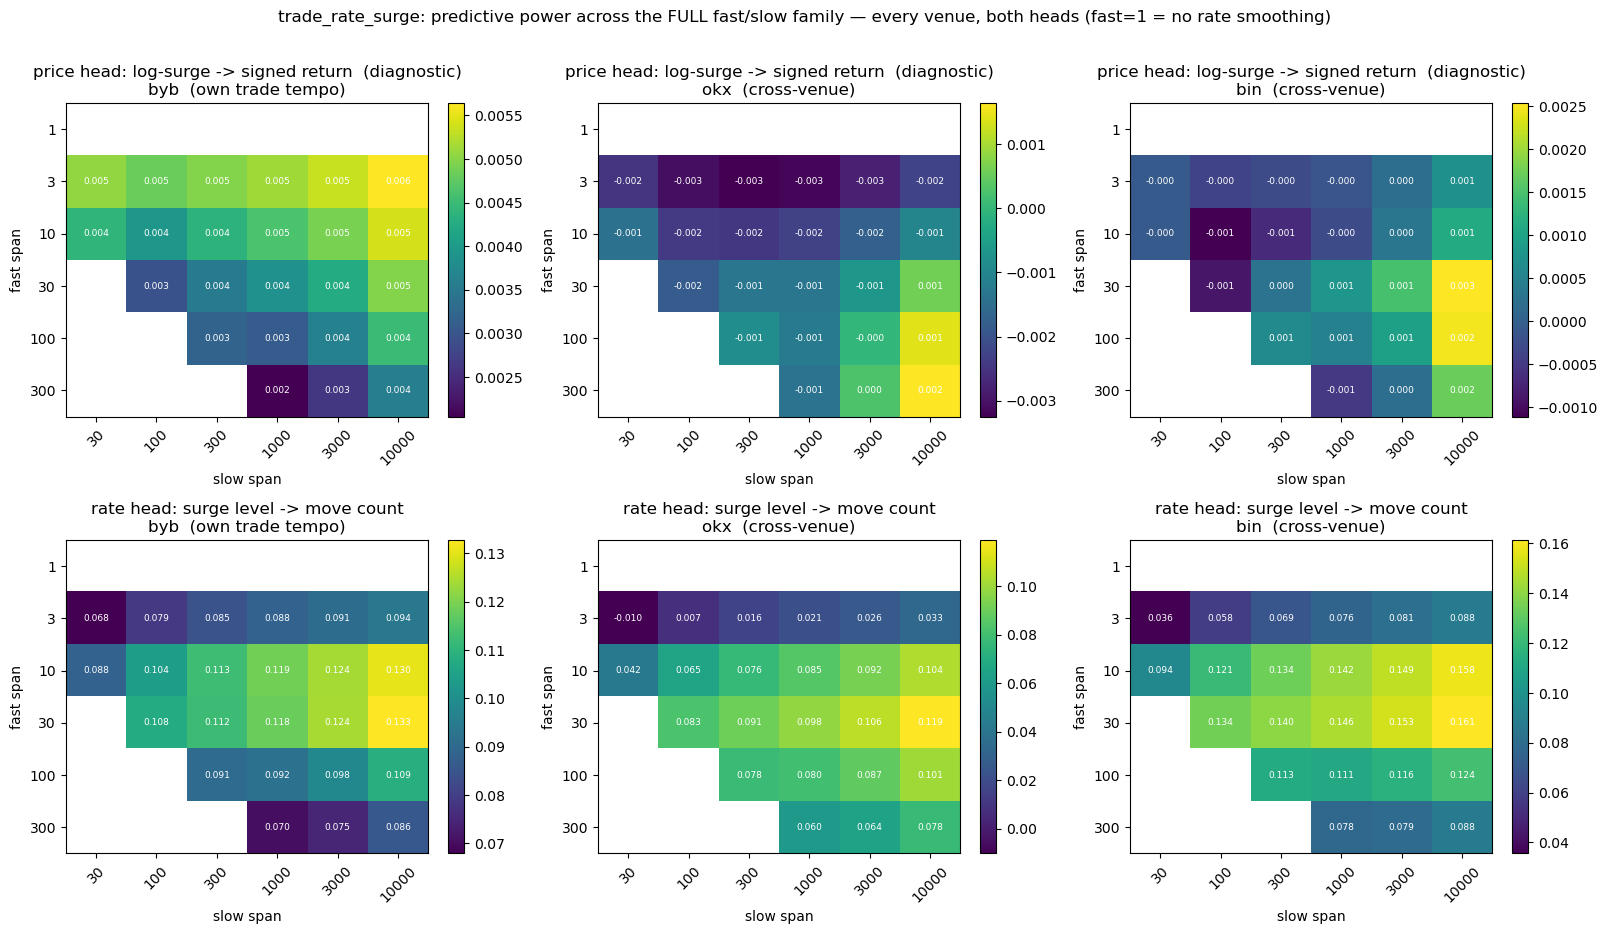

best family member per venue (in-sample pick; re-scored OOS below):
  byb:  price head (fast=3, slow=10000) IC=0.006   |  rate head (fast=30, slow=10000) IC=0.133
  okx:  price head (fast=3, slow=300) IC=-0.003   |  rate head (fast=30, slow=10000) IC=0.119
  bin:  price head (fast=30, slow=10000) IC=0.003   |  rate head (fast=30, slow=10000) IC=0.161


In [5]:
# Sweep the WHOLE family for EVERY venue, BOTH heads. Rate head uses the surge LEVEL (ratio) directly; price head uses log-surge.
price_grid = {ex: np.full((len(FAST), len(SLOW)), np.nan) for ex in EXCHANGES}   # log-surge -> byb's signed return
rate_grid  = {ex: np.full((len(FAST), len(SLOW)), np.nan) for ex in EXCHANGES}   # surge level -> byb's move count (rate_target)
feat_cache = {}
for ex in EXCHANGES:
    for i, nf in enumerate(FAST):
        for j, ns in enumerate(SLOW):
            if nf >= ns: continue
            s = trade_rate_surge(ex, nf, ns); feat_cache[(ex, nf, ns)] = s
            ls = np.log(np.maximum(s, 1e-12))                              # log surge: symmetric around 0, the natural signed form
            price_grid[ex][i, j] = spearmanr(ls, target).statistic        # price head (diagnostic — expected weak)
            rate_grid[ex][i, j]  = spearmanr(s, rate_target).statistic     # rate head — surge level -> move count

fig, axes = plt.subplots(2, len(EXCHANGES), figsize=(5.4 * len(EXCHANGES), 9.2), squeeze=False)
for row, (grids, head) in enumerate([(price_grid, "price head: log-surge -> signed return  (diagnostic)"),
                                     (rate_grid,  "rate head: surge level -> move count")]):
    for col, ex in enumerate(EXCHANGES):
        ax = axes[row][col]; grid = grids[ex]; im = ax.imshow(grid, cmap="viridis", aspect="auto")
        ax.set_xticks(range(len(SLOW))); ax.set_xticklabels(SLOW, rotation=45); ax.set_xlabel("slow span")
        ax.set_yticks(range(len(FAST))); ax.set_yticklabels(FAST); ax.set_ylabel("fast span")
        ax.set_title(f"{head}\n{ex}" + ("  (own trade tempo)" if ex == "byb" else "  (cross-venue)"))
        for i in range(len(FAST)):
            for j in range(len(SLOW)):
                if np.isfinite(grid[i, j]): ax.text(j, i, f"{grid[i, j]:.3f}", ha="center", va="center", color="w", fontsize=6.5)
        fig.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle("trade_rate_surge: predictive power across the FULL fast/slow family — every venue, both heads (fast=1 = no rate smoothing)", y=1.01)
fig.tight_layout(); plt.show()

# In-sample pick of the best family member PER head PER venue (used only to choose a time-scale; re-scored OOS by the gates).
def best_member(grid): return np.unravel_index(np.nanargmax(np.abs(grid)), grid.shape)
price_member = {ex: best_member(price_grid[ex]) for ex in EXCHANGES}
rate_member  = {ex: best_member(rate_grid[ex])  for ex in EXCHANGES}
print("best family member per venue (in-sample pick; re-scored OOS below):")
for ex in EXCHANGES:
    pi, pj = price_member[ex]; ri, rj = rate_member[ex]
    print(f"  {ex}:  price head (fast={FAST[pi]}, slow={SLOW[pj]}) IC={price_grid[ex][pi,pj]:.3f}"
          f"   |  rate head (fast={FAST[ri]}, slow={SLOW[rj]}) IC={rate_grid[ex][ri,rj]:.3f}")

does a 2nd span add over the pick? — price head: conditional partial-IC (in-sample screen) + walk-forward joint-vs-solo OOS:


/var/folders/m3/7cjs9hdj1qlgdfh3tq_9txmm0000gn/T/ipykernel_91197/1719204262.py:4: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rfy = spearmanr(f[m], y[m]).statistic; rfc = spearmanr(f[m], c[m]).statistic; rcy = spearmanr(c[m], y[m]).statistic


  byb: best alt (f=3,s=3000) IC|best -0.005;  OOS joint +0.004 vs solo -0.004 (Δ+0.008)  ->  one span suffices (no OOS gain)


/var/folders/m3/7cjs9hdj1qlgdfh3tq_9txmm0000gn/T/ipykernel_91197/1719204262.py:4: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rfy = spearmanr(f[m], y[m]).statistic; rfc = spearmanr(f[m], c[m]).statistic; rcy = spearmanr(c[m], y[m]).statistic


  okx: best alt (f=3,s=10000) IC|best +0.003;  OOS joint +0.001 vs solo -0.002 (Δ+0.003)  ->  one span suffices (no OOS gain)


...

  byb: best alt (f=100,s=300) IC|best -0.034;  OOS joint +0.125 vs solo +0.125 (Δ+0.000)  ->  one span suffices (no OOS gain)


/var/folders/m3/7cjs9hdj1qlgdfh3tq_9txmm0000gn/T/ipykernel_91197/1719204262.py:4: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rfy = spearmanr(f[m], y[m]).statistic; rfc = spearmanr(f[m], c[m]).statistic; rcy = spearmanr(c[m], y[m]).statistic


  okx: best alt (f=3,s=3000) IC|best -0.032;  OOS joint +0.111 vs solo +0.115 (Δ-0.003)  ->  one span suffices (no OOS gain)


/var/folders/m3/7cjs9hdj1qlgdfh3tq_9txmm0000gn/T/ipykernel_91197/1719204262.py:4: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rfy = spearmanr(f[m], y[m]).statistic; rfc = spearmanr(f[m], c[m]).statistic; rcy = spearmanr(c[m], y[m]).statistic


  bin: best alt (f=10,s=30) IC|best +0.067;  OOS joint +0.136 vs solo +0.155 (Δ-0.019)  ->  one span suffices (no OOS gain)


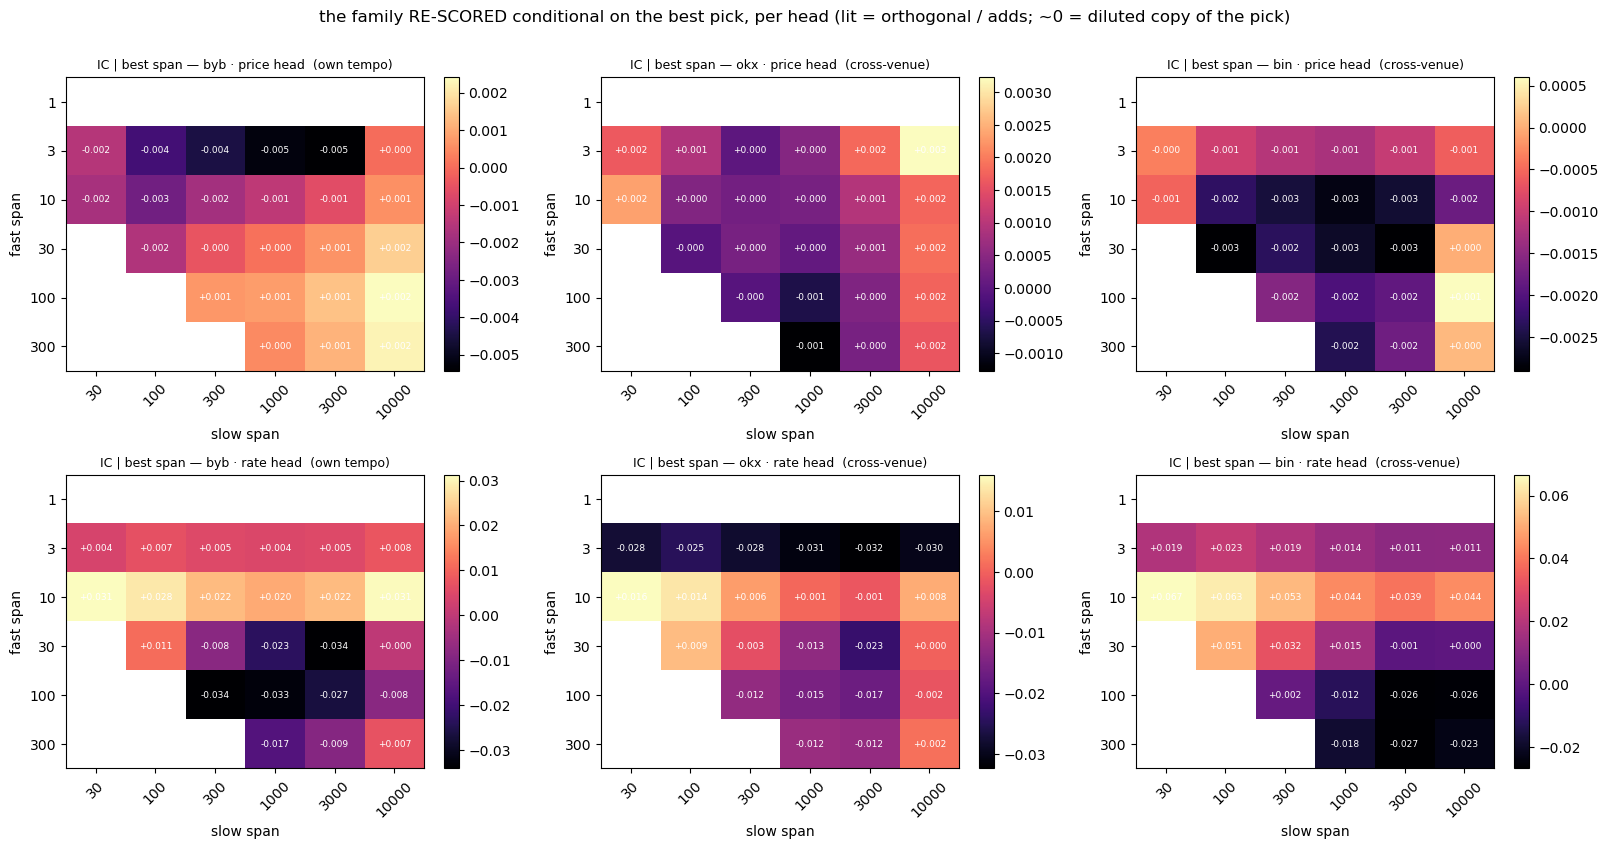

In [6]:
def _pic(f, y, c):                                                   # partial rank-IC of f with y, controlling for c
    m = np.isfinite(f) & np.isfinite(y) & np.isfinite(c)
    if m.sum() <= 100: return np.nan
    rfy = spearmanr(f[m], y[m]).statistic; rfc = spearmanr(f[m], c[m]).statistic; rcy = spearmanr(c[m], y[m]).statistic
    return (rfy - rfc * rcy) / np.sqrt(max((1.0 - rfc**2) * (1.0 - rcy**2), 1e-12))

# Per head: feat() maps a cell to its scored feature (rate head = surge LEVEL; price head = signed log-surge),
# tgt is the head's target, member is the in-sample pick. Every venue (byb included) — no assumed leader.
HEADS = [("price head", lambda ex, nf, ns: np.log(np.maximum(trade_rate_surge(ex, nf, ns), 1e-12)), target,      price_member),
         ("rate head",  lambda ex, nf, ns: trade_rate_surge(ex, nf, ns),                            rate_target, rate_member)]
fig, axes = plt.subplots(len(HEADS), len(EXCHANGES), figsize=(5.4 * len(EXCHANGES), 4.2 * len(HEADS)), squeeze=False)
second = {}
for row, (head, feat, tgt, member) in enumerate(HEADS):
    print(f"does a 2nd span add over the pick? — {head}: conditional partial-IC (in-sample screen) + walk-forward joint-vs-solo OOS:")
    for col, ex in enumerate(EXCHANGES):
        ci, cj = member[ex]; chosen = feat(ex, FAST[ci], SLOW[cj])
        cond = np.full((len(FAST), len(SLOW)), np.nan)
        for i, nf in enumerate(FAST):
            for j, ns in enumerate(SLOW):
                if nf < ns: cond[i, j] = 0.0 if (i, j) == (ci, cj) else _pic(feat(ex, nf, ns), tgt, chosen)
        ax = axes[row][col]; im = ax.imshow(cond, cmap="magma", aspect="auto")
        ax.set_xticks(range(len(SLOW))); ax.set_xticklabels(SLOW, rotation=45); ax.set_xlabel("slow span")
        ax.set_yticks(range(len(FAST))); ax.set_yticklabels(FAST); ax.set_ylabel("fast span")
        ax.set_title(f"IC | best span — {ex} · {head}" + ("  (own tempo)" if ex == "byb" else "  (cross-venue)"), fontsize=9)
        for i in range(len(FAST)):
            for j in range(len(SLOW)):
                if np.isfinite(cond[i, j]): ax.text(j, i, f"{cond[i, j]:+.3f}", ha="center", va="center", color="w", fontsize=6.5)
        fig.colorbar(im, ax=ax, fraction=0.046)
        bi, bj = np.unravel_index(np.nanargmax(np.abs(cond)), cond.shape)          # the most-orthogonal alternative cell (in-sample screen)
        f1, f2 = chosen, feat(ex, FAST[bi], SLOW[bj])
        solo, joint = wf_ic([f1], tgt), wf_ic([f1, f2], tgt)                       # OOS: chosen alone vs the pair
        keep = bool((joint - solo) >= 0.01)                                        # the OOS joint gain DECIDES
        second[(head, ex)] = (bi, bj) if keep else None
        print(f"  {ex}: best alt (f={FAST[bi]},s={SLOW[bj]}) IC|best {cond[bi, bj]:+.3f};  OOS joint {joint:+.3f} vs solo {solo:+.3f} (Δ{joint - solo:+.3f})"
              f"  ->  {'KEEP 2nd span (adds OOS)' if keep else 'one span suffices (no OOS gain)'}")
fig.suptitle("the family RE-SCORED conditional on the best pick, per head (lit = orthogonal / adds; ~0 = diluted copy of the pick)", y=1.005)
fig.tight_layout(); plt.show()

**Does a *second* time-scale add — per head?** The IC heat-map picks the best span per head; a second span is only
worth feeding if it carries signal the first doesn't. We test that by **re-scoring the whole family conditional on
the chosen pick** — each cell's IC recomputed as `partial-IC(cell | chosen)`: its predictive power against the
head's target **controlling for the span we already picked** (the same partial-IC tool the echo-netting cell
uses; control = the chosen span). A cell that stays **lit** is **orthogonal** — it adds new signal — while
a cell that **collapses to ≈ 0** is a diluted copy of the pick. Because that heat-map is **in-sample**, the
keep/drop **decision** is the overfitting-resistant **walk-forward joint-vs-solo** IC
(`wf_ic([chosen, alt]) − wf_ic([chosen])`): keep the second span only when the out-of-sample gain clears the ~0.01
floor. We run it for **both heads** (price → signed log-surge vs the σ-return target; rate → surge level vs the
count target), **per venue**. On this block both heads find the second span a diluted copy (OOS gain ≈ 0), so one
span per head per venue suffices.

**Now the gates** — and they are **two independent tests**, not one. Every *predictive* number is the
**walk-forward** mean (causal, purged).

One caveat for **both heads**: the fast/slow span is chosen by the in-sample heat-map *above* over the
**whole** block, so the walk-forward IC below is **post-selection and provisional** — mildly optimistic,
since the test folds also informed the span pick. Held-out span selection is deferred to the multi-block
`tools/oss` harness; here the choice is among a small 6×6 fast/slow grid of near-identical neighbours, so
the selection bias is expected to be small (we don't measure it on this single block).

**Gate A — regime invariance** (the feature *alone*): is the feature's distribution **stable against our regime
diagnostics**, or does it *leak* it? **Control-free** checks: **scale** — its std across vol buckets (max/min,
want **< ~3**); and then, for **both the signed feature *and* its magnitude `|feature|`** (the rate head
receives the *signed* feature and can learn its magnitude), two leak modes against **both regime coordinates**
(vol *and* rate level): **tracking** — `|IC(·, level)|` ≈ 0 (the monotone test, want **< ~0.05** for the
signed feature, **< ~0.1** for the magnitude), and **dispersion** — the spread of its per-decile *means*
(want **< ~0.1**), which catches a *non-monotone* leak the monotone IC misses. The vol/rate level is only the
regime *coordinate* here (what we bucket/correlate against), **never** a control. Fail any one of them = a
level in disguise, not a feature. *(For a dimensionless surge **ratio** we expect scale to be steady and
tracking small — but `trade_rate_surge` is a trade-tempo regime descriptor, and a venue's trade tempo
correlates with byb's vol/rate regime, so this is exactly where a leak could appear; we measure, never
assume.)*

**Gate B — predictive signal**: does it predict? `trade_rate_surge` is a **control** (a trade-tempo regime
descriptor), but — the crux — the controls are the **move** rate while the feature is the **trade** rate,
and trade rate ≠ move rate, so there is **no circular own-leg** here. Every leg (byb, okx, bin) is judged on
its **marginal** rank-IC over the regime-invariant controls (the momenta — **never** the raw levels),
`own=False` — the honest "does trade tempo add over move tempo?" test, jointly and per leg. **Mechanical-
coupling guard:** the surge is `trade_rate_fast / trade_rate_slow` and `trade_rate = T/dt`, so the `dt` and
the `λ_ev` scale **cancel** — it divides by **no** yardstick of either target — so there is no spurious ratio
coupling to stratify away (`STRAT_VAR = None`). *Regime-stable* (companion): is the gain still positive
**within** calm, mid, and wild vol — not a one-regime artefact?

In [7]:
# Gates on the set of per-venue features — symmetric; KEEP ALL venues. We run the RATE head (the feature's home).
# GATE B — predictive signal.  trade_rate_surge is a CONTROL (a trade-tempo regime descriptor), BUT the control is the
# MOVE rate while the feature is the TRADE rate (trade rate != move rate), so there is NO circular own-leg: EVERY leg
# (byb included) is judged on its MARGINAL rank-IC over the base momenta -> own=False (the honest "trade tempo over move tempo" test).
# signal_ic / signal_ic_by_regime / stratified_ic / ic all come from boba.research.gates (the §5 wrappers bind
# base / FEATURE_KIND / STRAT_VAR / vol_regime). STRAT_VAR=None (the surge divides by no yardstick), so the marginal
# branch is the usual nested-model incremental IC for every leg.
surge = {ex: feat_cache[(ex, FAST[rate_member[ex][0]], SLOW[rate_member[ex][1]])] for ex in EXCHANGES}  # rate-head pick per venue

# rate head, scored against the COUNT target. EVERY leg (byb included) -> marginal-over-controls (own=False).
each_marg   = {ex: signal_ic([surge[ex]], own=False, tgt=rate_target) for ex in EXCHANGES}              # per-leg marginal over the MOVE-rate controls
joint_marg  = signal_ic(list(surge.values()), own=False, tgt=rate_target)                               # all three legs jointly
cross_joint = signal_ic([surge["okx"], surge["bin"]], own=False, tgt=rate_target)                       # okx+bin cross-venue legs only
jci = wf_marginal_ci(list(surge.values()), rate_target)   # per-fold spread + block-bootstrap CI for the joint marginal
strat = signal_ic_by_regime(list(surge.values()), own=False, tgt=rate_target)  # the calm/mid/wild companion (all legs)
print(f"byb OWN-trade-tempo marginal (over the MOVE-rate controls) {each_marg['byb']:.3f}  <- the trade-rate-vs-move-rate test")
print(f"all three legs JOINT marginal {joint_marg:.3f}  |  per-fold {jci['per_fold']} (positive in {jci['pos']}/{jci['nf']})  "
      f"|  block-bootstrap 90% CI [{jci['ci'][0]}, {jci['ci'][1]}]  (block ~{jci['block_len']} anchors ~{jci['block_s']}s)")
print(f"okx+bin CROSS-VENUE joint marginal {cross_joint:.3f}")

# LOW-1 sanity: a "control" SHOULD overlap the momenta (it IS a regime descriptor) — but the TRADE rate need not overlap
# the MOVE-rate momenta as strongly as mid_rate_surge's byb leg did (0.31), since trade rate != move rate.
rep = surge["byb"]
print(f"FEATURE_KIND={FEATURE_KIND!r} | byb trade-surge vs momenta |IC|: rate {abs(ic(rep, rate_momentum)):.3f} vol {abs(ic(rep, vol_momentum)):.3f}  (vs MOVE-rate momentum: how much the trade tempo tracks the move tempo)")

gate_rows = [dict(gate="B · signal (rate)", detail=f"{ex} leg alone — marginal surge->count over the MOVE-rate controls"
                  + ("  [byb own trade tempo vs MOVE-rate control]" if ex == "byb" else "  [cross-venue trade tempo]"),
                  value=each_marg[ex]) for ex in EXCHANGES]
gate_rows += [dict(gate="B · signal (rate)", detail="all three venues JOINTLY — marginal over the controls", value=joint_marg),
              dict(gate="B · signal (rate)", detail="okx+bin cross-venue legs JOINTLY — marginal over the controls", value=cross_joint)]
for ex in EXCHANGES:                                       # GATE A PER VENUE (worst coordinate per check) — the output distribution differs by venue
    a = gate_a(surge[ex])
    gate_rows += [dict(gate=f"A · regime-inv ({ex})", detail="feature scale across vol buckets (max/min) — HARD, want < ~3", value=a["scale"]),
                  dict(gate=f"A · regime-inv ({ex})", detail="|IC(feature, vol/rate level)| — signed mean-track, worst coord; want < ~0.05", value=a["track"]),
                  dict(gate=f"A · regime-inv ({ex})", detail="|IC(|feature|, vol/rate level)| — magnitude track (the signed-fed rate head can learn it), worst coord; want < ~0.1", value=a["mag"]),
                  dict(gate=f"A · regime-inv ({ex})", detail="non-monotone leak — per-decile-mean dispersion (mean & magnitude), worst; want < ~0.1", value=a["disp"])]
gate_rows += [dict(gate="regime-stable (rate)", detail=f"joint marginal within {nm}-vol (companion: stay positive)", value=strat.get(r, float("nan")))
              for r, nm in [(0, "calm"), (1, "mid"), (2, "wild")]]
pl.Config.set_tbl_rows(30); pl.Config.set_fmt_str_lengths(70)
pl.DataFrame(gate_rows)

byb OWN-trade-tempo marginal (over the MOVE-rate controls) 0.052  <- the trade-rate-vs-move-rate test
all three legs JOINT marginal 0.090  |  per-fold [0.079, 0.101, 0.08, 0.093, 0.096] (positive in 5/5)  |  block-bootstrap 90% CI [0.085, 0.094]  (block ~9479 anchors ~474.0s)
okx+bin CROSS-VENUE joint marginal 0.087


FEATURE_KIND='control' | byb trade-surge vs momenta |IC|: rate 0.358 vol 0.018  (vs MOVE-rate momentum: how much the trade tempo tracks the move tempo)


gate,detail,value
str,str,f64
"""B · signal (rate)""","""byb leg alone — marginal surge->count over the MOVE-rate controls [by…",0.052
"""B · signal (rate)""","""okx leg alone — marginal surge->count over the MOVE-rate controls [cr…",0.051
"""B · signal (rate)""","""bin leg alone — marginal surge->count over the MOVE-rate controls [cr…",0.084
"""B · signal (rate)""","""all three venues JOINTLY — marginal over the controls""",0.09
"""B · signal (rate)""","""okx+bin cross-venue legs JOINTLY — marginal over the controls""",0.087
"""A · regime-inv (byb)""","""feature scale across vol buckets (max/min) — HARD, want < ~3""",1.41
"""A · regime-inv (byb)""","""|IC(feature, vol/rate level)| — signed mean-track, worst coord; want <…",0.018
"""A · regime-inv (byb)""","""|IC(|feature|, vol/rate level)| — magnitude track (the signed-fed rate…",0.018
"""A · regime-inv (byb)""","""non-monotone leak — per-decile-mean dispersion (mean & magnitude), wor…",0.055


**Conclusion — read per leg, against the trade-rate-vs-move-rate distinction.** `trade_rate_surge` is a
**control** (a trade-tempo regime descriptor), and the headline numbers are the **marginal values over the
move-rate/vol momenta** on the **rate head**, reported straight. The key contrast with `mid_rate_surge`:
there the byb leg *was* a near-twin of `rate_momentum` and added ≈0 (forced to a standalone read); **here
the control is the *move* rate while the feature is the *trade* rate**, so even the **byb** leg is judged on
its **marginal**. And on this block the thesis holds: **byb's own trade-rate surge adds +0.052 marginal over
the move-rate controls** — not ≈0 — even though its overlap with `rate_momentum` is high (|IC| **0.358**).
So trade tempo *does* carry intensity the move-rate regime misses, the headline finding that distinguishes
this feature from `mid_rate_surge`. The **okx** (**+0.051**) and **bin** (**+0.084**) cross-venue legs add
on top; **jointly** all three give **+0.090**, positive in **5/5** OOS folds with a tight block-bootstrap
90% CI **[0.085, 0.094]**, and the **okx+bin cross-venue** legs alone give **+0.087** — so another venue's
trade tempo genuinely leads byb's move-count (the byb own leg adds only a hair on top of the cross-venue
pair, 0.090 vs 0.087, but is positive standalone). **Gate A** is run per venue (a distribution property):
scale is steady (**1.41 / 1.56 / 1.97**, all ≪ 3) and byb/okx barely track the regime (signed mean-track
**0.018 / 0.032**, under the ~0.05 bar), but **bin** *does* track it (**0.114**, above the signed bar) —
which is allowed here: `trade_rate_surge` is a **trade-tempo regime descriptor**, so a venue's trade tempo
correlating with byb's `rate_level`/`λ_ev` is the feature being honest about what it is, not a disqualifying
"level in disguise" (dispersion stays small everywhere, **0.055 / 0.031 / 0.035**, so no non-monotone leak).
The companion confirms the joint marginal is **not** a one-regime artefact — **0.085 / 0.093 / 0.087** for
calm / mid / wild. We quote the **§6 marginal**, never a raw IC.

## Is the edge real prediction, or an echo of the move already underway?

A feature can be perfectly causal and still not *predict*: if its apparent edge is the price move **already
underway** at the anchor, you can't capture it — by the time you observe, decide, and act, that move is gone — and
a purely *contemporaneous* feature can post a positive forward IC from window overlap alone. So before trusting a
forward IC, **net out the echo**: measure the feature's correlation with the **forward** return
(`[anchor, anchor+100 ms]`) *controlling for the move that already happened* (`[anchor−100 ms, anchor]`). The
**backward IC** sizes the echo; the **echo-netted** forward IC is what survives once it's partialled out — the
genuinely forward-looking edge. (It's the same partial-IC tool §6 uses to test a second time-scale — here the
control is the trailing move instead of the chosen span.)

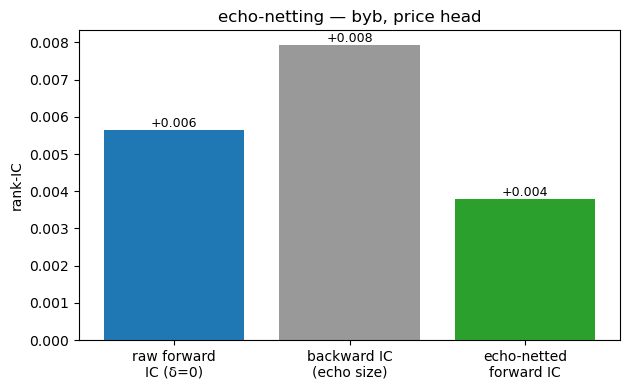

raw forward IC +0.006;  backward (echo) IC +0.008;  echo-netted forward IC +0.004  (the raw->netted shortfall is echo)


In [8]:
# Echo-netting: is the edge real prediction, or just re-reporting the move ALREADY underway at the anchor?
rep_ex = EXCHANGES[0]                                    # one venue to illustrate; every leg carries its own
def _ic(feat, ret):
    v = np.isfinite(feat) & np.isfinite(ret)
    return spearmanr(feat[v], ret[v]).statistic if v.sum() > 100 else float("nan")
def _mid_at(t):                                          # byb merged mid at-or-before t (causal)
    idx = np.searchsorted(byb_rx, t, "right") - 1; return np.where(idx < 0, np.nan, byb_mid[np.clip(idx, 0, len(byb_mid) - 1)])   # nan before byb's first quote
def _ret(t0, t1): return np.log(_mid_at(t1) / _mid_at(t0))
def _partial_ic(f, y, t):                                # partial rank-IC of f with y, CONTROLLING for t
    v = np.isfinite(f) & np.isfinite(y) & np.isfinite(t)
    if v.sum() <= 100: return float("nan")
    rfy = spearmanr(f[v], y[v]).statistic; rft = spearmanr(f[v], t[v]).statistic; rty = spearmanr(t[v], y[v]).statistic
    return (rfy - rft*rty) / np.sqrt(max((1.0 - rft**2) * (1.0 - rty**2), 1e-12))

signed = np.log(np.maximum(trade_rate_surge(rep_ex, FAST[price_member[rep_ex][0]], SLOW[price_member[rep_ex][1]]), 1e-12))   # the chosen price-head feature (signed log-surge)
_fwd0  = _ret(anchor_ts, anchor_ts + HORIZON_NS)          # forward 100 ms return — what we predict
_trail = _ret(anchor_ts - HORIZON_NS, anchor_ts)          # the move ALREADY underway at the anchor
raw_ic   = _ic(signed, _fwd0)                             # raw forward IC
back_ic  = _ic(signed, _trail)                            # backward IC — sizes the contemporaneous echo
echo_net = _partial_ic(signed, _fwd0, _trail)             # forward IC NETTED of the echo (controls for the trailing move)

fig, ax = plt.subplots(figsize=(6.4, 4.0))
labels = ["raw forward\nIC (δ=0)", "backward IC\n(echo size)", "echo-netted\nforward IC"]
vals = [raw_ic, back_ic, echo_net]
bars = ax.bar(labels, vals, color=["C0", "0.6", "C2"])
ax.axhline(0, color="0.7", lw=0.8); ax.set_ylabel("rank-IC"); ax.set_title(f"echo-netting — {rep_ex}, price head")
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v, f"{v:+.3f}", ha="center", va="bottom" if v >= 0 else "top", fontsize=9)
fig.tight_layout(); plt.show()
print(f"raw forward IC {raw_ic:+.3f};  backward (echo) IC {back_ic:+.3f};  echo-netted forward IC {echo_net:+.3f}  (the raw->netted shortfall is echo)")

**Net the echo out — don't report a forward IC a contemporaneous predictor could fake.** The cleanest
"is this real prediction?" number is the **echo-netted (partial) forward IC** above: the feature's rank-IC with
the *forward* return *controlling for the trailing* `[anchor−100 ms, anchor]` return. If a big raw IC collapses
once the trailing move is partialled out, the feature was mostly re-reporting the move already underway — report
the **netted** number in the verdict, not the raw IC. (A near-zero netted IC alongside a large backward IC is the
one true non-signal: all echo, no prediction.)

**Cross-venue legs: a freshness lead is *real edge*, not an artifact to coarsen away.** The data is recorded
on a production box in the target datacenter, so each event's `rx_time` is exactly the timing you'd see live —
there is **no recording/snapshot artifact** to rule out. So when okx's book moves before byb's reflects it
(byb/okx top-of-book is stale p90 ~100–160 ms vs bin's sub-ms), that lead is **genuine and exploitable**, and
the *mechanism* (economic price-discovery vs pure latency lead-lag) is irrelevant to P&L. Do **not** coarsen the
foreign feed to byb's cadence — that throws the edge away. *(A freshness lead would only be fake if the
recording's cadence didn't match production — e.g. a backtest on vendor snapshots; not the case here, where the
recording* is *production timing.)*

## 7. What the prediction actually looks like

A single correlation hides *how* the feature changes the outcome. Group the data by the feature and look
at the real distributions the heads care about, **per venue** (byb's own tempo vs the cross-venue legs):
- **rate head (its home):** how the number of upcoming byb moves grows as each venue's trade-surge ratio grows;
- **price head (diagnostic):** byb's next return for low / middle / high *signed* (log-)surge — expected
  roughly flat, since intensity isn't direction.

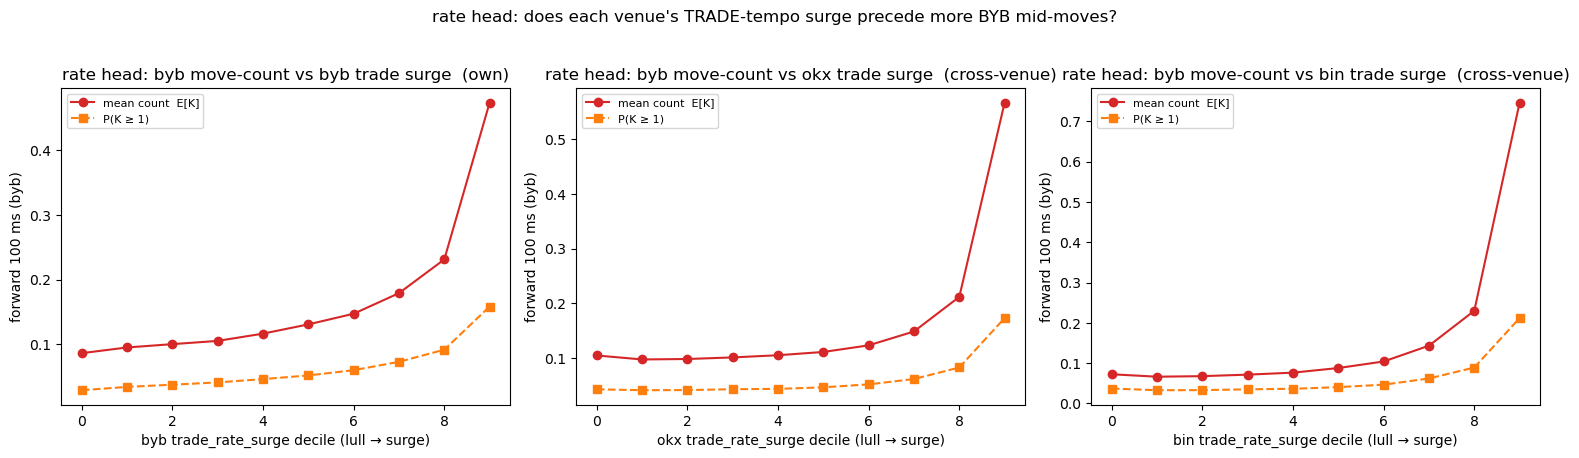

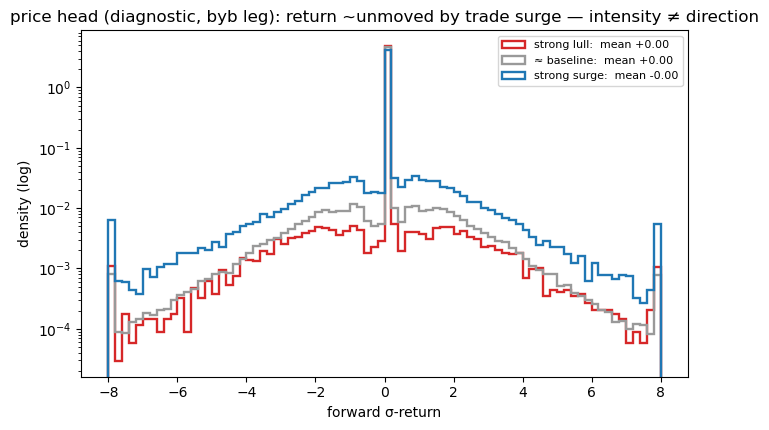

In [9]:
fig, axes = plt.subplots(1, len(EXCHANGES), figsize=(5.2 * len(EXCHANGES), 4.4), squeeze=False)
for col, ex in enumerate(EXCHANGES):
    s = surge[ex]; ax = axes[0][col]
    dec = np.digitize(s, np.nanpercentile(s[np.isfinite(s)], np.arange(10, 100, 10)))
    ax.plot(range(10), [fwd_count[dec == b].mean() for b in range(10)], "o-", color="C3", label="mean count  E[K]")
    ax.plot(range(10), [(fwd_count[dec == b] >= 1).mean() for b in range(10)], "s--", color="C1", label="P(K ≥ 1)")
    ax.set_xlabel(f"{ex} trade_rate_surge decile (lull → surge)"); ax.set_ylabel("forward 100 ms (byb)")
    ax.set_title(f"rate head: byb move-count vs {ex} trade surge" + ("  (own)" if ex == "byb" else "  (cross-venue)")); ax.legend(fontsize=8)
fig.suptitle("rate head: does each venue's TRADE-tempo surge precede more BYB mid-moves?", y=1.03)
fig.tight_layout(); plt.show()

# price head (diagnostic): forward σ-return across signed log-surge buckets — expected ~flat — shown for the byb leg
s = surge["byb"]; ls = np.log(np.maximum(s, 1e-12))
fig, axB = plt.subplots(1, 1, figsize=(7, 4.4))
lo, hi = np.nanpercentile(ls, [10, 90])
groups = [("strong lull", ls <= lo, "C3"), ("≈ baseline", (ls > lo) & (ls < hi), "0.6"), ("strong surge", ls >= hi, "C0")]
bins = np.linspace(-8, 8, 81)
for lab, m, col in groups:
    axB.hist(np.clip(target[m & np.isfinite(target)], -8, 8), bins=bins, density=True,
             histtype="step", color=col, lw=1.7, label=f"{lab}:  mean {np.nanmean(target[m]):+.2f}")
axB.set_yscale("log"); axB.set_xlabel("forward σ-return"); axB.set_ylabel("density (log)")
axB.set_title("price head (diagnostic, byb leg): return ~unmoved by trade surge — intensity ≠ direction"); axB.legend(fontsize=8)
fig.tight_layout(); plt.show()

**Conclusion.** **Rate head (top row):** read the per-venue panels for this block — for the **byb** leg the
mean move-count `E[K]` and `P(K ≥ 1)` track the venue's trade-surge deciles (the §1 intensity story: a trade
surge precedes more byb moves), and the **okx/bin** panels show whether *another* venue's trade surge also
tracks byb's upcoming move-count (a cross-venue lead, quantified by the §6 marginals). **Price head
(bottom):** the forward-return distribution barely shifts across lull / baseline / surge groups (group means
≈ 0) — a surge says *how many*, not *which way*, confirming this is an intensity feature. So the feature
moves the actual outcome distributions the rate head needs, and the open question §6/§9 answers is whether
any leg's signal is **new** over `rate_momentum` — and here, because the control is the *move* rate and this
is the *trade* rate, even byb's own leg has a genuine shot.

## 8. Input shaping for the network

This reshapes the feature for the network's input — roughly centred, unit-scale, no wild outliers — a
*different* step from §2 (there is no regime division here; the feature is already a ratio). A surge
*ratio* is positive and right-skewed, so its **log** is the natural signed, centred form. We feed **every
venue's** log-surge (none privileged). Plot the byb leg (left) and compare candidates by how close to a
clean bell curve they make it (right — points on the diagonal are perfectly normal). Pick the lightest
transform that clears the bar; the same transform applies per venue.

raw ratio: skew=+34.27  excess_kurt=3048.7
log surge: skew=-0.72  excess_kurt=20.8  (0 = normal)
  raw ratio (z)          excess_kurt=3048.7   max|·|=207.6
  log surge (z)          excess_kurt=  20.8   max|·|=36.0
  log robust + clip ±4   excess_kurt=   1.0   max|·|=4.0
  rank-Gaussian(log)     excess_kurt=  -0.0   max|·|=5.0


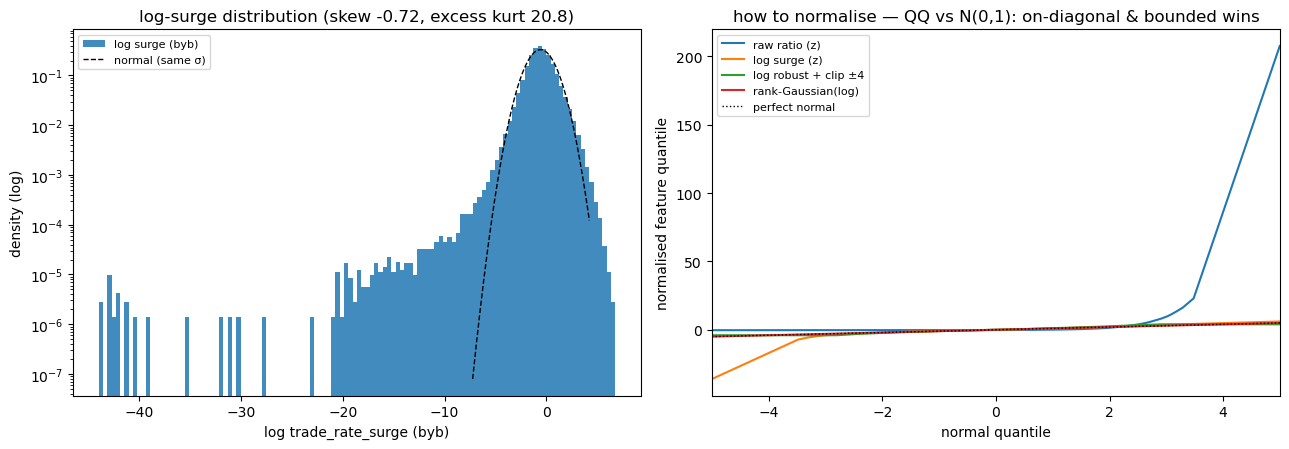

In [10]:
from scipy.stats import skew, kurtosis, rankdata, norm
f = surge["byb"]; f = f[np.isfinite(f) & (f > 0)]
lf = np.log(f)                                       # log surge: the natural centred, signed form of a ratio
med = np.median(lf); mad = 1.4826 * np.median(np.abs(lf - med)) + 1e-12; rz = (lf - med) / mad
cand = {"raw ratio (z)": (f - f.mean()) / f.std(),
        "log surge (z)": (lf - lf.mean()) / lf.std(),
        "log robust + clip ±4": np.clip(rz, -4, 4),
        "rank-Gaussian(log)": norm.ppf((rankdata(lf) - 0.5) / len(lf))}
print(f"raw ratio: skew={skew(f):+.2f}  excess_kurt={kurtosis(f):.1f}")
print(f"log surge: skew={skew(lf):+.2f}  excess_kurt={kurtosis(lf):.1f}  (0 = normal)")
for name, v in cand.items():
    print(f"  {name:22} excess_kurt={kurtosis(v):>6.1f}   max|·|={np.abs(v).max():.1f}")

fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 4.6))
axA.hist(lf, bins=120, density=True, color="C0", alpha=.85, label="log surge (byb)")
xg = np.linspace(np.percentile(lf, 0.05), np.percentile(lf, 99.95), 300)
axA.plot(xg, norm.pdf(xg, lf.mean(), lf.std()), "k--", lw=1, label="normal (same σ)")
axA.set_yscale("log"); axA.set_xlabel("log trade_rate_surge (byb)"); axA.set_ylabel("density (log)")
axA.set_title(f"log-surge distribution (skew {skew(lf):+.2f}, excess kurt {kurtosis(lf):.1f})"); axA.legend(fontsize=8)

q = norm.ppf((np.arange(1, len(lf) + 1) - 0.5) / len(lf)); sub = np.linspace(0, len(lf) - 1, 4000).astype(int)
for name, v in cand.items():
    axB.plot(q[sub], np.sort(v)[sub], lw=1.5, label=name)
axB.plot([-5, 5], [-5, 5], "k:", lw=1, label="perfect normal")
axB.set_xlim(-5, 5); axB.set_xlabel("normal quantile"); axB.set_ylabel("normalised feature quantile")
axB.set_title("how to normalise — QQ vs N(0,1): on-diagonal & bounded wins"); axB.legend(fontsize=8)
fig.tight_layout(); plt.show()

**Conclusion.** The raw surge ratio is violently right-skewed and fat-tailed (skew **+34.3**, excess
kurtosis **3049**, max|·| **208** as a z-score) — unusable raw. Taking the **log** pulls most of that in
(skew **−0.72**, excess kurtosis **20.8**), but a plain z-score of the log still leaves a heavy tail
(max|·| **36.0**), so it does **not** clear the "no wild outliers" bar on its own. The lightest transform
that *does* is **log → robust-z → clip ±4** (excess kurtosis **1.0**, max|·| **4.0**) — that is what to feed
the network. The heavier rank-Gaussian flattens the tail to a clean bell (excess kurtosis ≈ 0) but throws
information away. So: feed `log(trade_rate_surge)` per venue, robust-standardised and clipped — every venue,
none privileged. And unlike `mid_rate_surge` (whose byb leg is a near-duplicate of `rate_momentum` and added
≈0), here even the byb leg carries marginal value over the rate control (§6 +0.052), since this is the
*trade* rate, not the *move* rate.

## 9. When is per-exchange worth it? — short vs long lookback

`trade_rate_surge` is a **poolable** per-venue feature (one surge per venue), so the template's real
per-exchange question *does* apply here: keep them **per-exchange**, collapse to a **single** venue, or
**pool** them? The answer depends on the time-scale — so we sweep the **slow** span (the lookback) and
compare the three, walk-forward, on the rate head. (This is a genuine computation, not an illustrative
note: a per-venue surge *can* be pooled, unlike the template's cross-venue gap.)

**The mechanism, and what to expect.** The cross-venue edge is a **trade-tempo lead/lag** — one venue
trading hard a beat before another. At **short** lookbacks the venues genuinely differ (who is
accelerating first), so the per-venue set carries distinct cross-venue lead/lag and should beat a single
venue; at **long** lookbacks every venue's smoothed tempo converges to the same slow activity regime, so a
**single** venue already says what the rest do and the extra legs are redundant. We compute, at each slow
span (fast leg fixed short): the **per-exchange** marginal (all three legs), the **single best** venue's
marginal, and the **pooled** (mean log-surge across venues) marginal — each over the controls, walk-forward.
The **cross-venue-only** (okx+bin) curve isolates whether another venue's trade tempo leads byb's
move-count beyond byb's own.

In [11]:
# Sweep the lookback (slow span); fast leg fixed short so the rate stays responsive. Compare per-exchange / single / pooled.
FAST_FIX = 3                                                            # a short, responsive fast leg held fixed across the sweep
look_rows = []
for ns in SLOW:
    if ns <= FAST_FIX: continue
    legs = {ex: trade_rate_surge(ex, FAST_FIX, ns) for ex in EXCHANGES}  # one surge per venue at this lookback
    per_ex  = round(wf_ic(base + list(legs.values()), rate_target) - wf_ic(base, rate_target), 3)   # all three legs
    singles = {ex: round(wf_ic(base + [legs[ex]], rate_target) - wf_ic(base, rate_target), 3) for ex in EXCHANGES}
    best_ex = max(singles, key=singles.get); single = singles[best_ex]
    logs    = [np.log(np.maximum(legs[ex], 1e-12)) for ex in EXCHANGES]
    pooled  = round(wf_ic(base + [np.nanmean(np.column_stack(logs), axis=1)], rate_target) - wf_ic(base, rate_target), 3)
    cross   = round(wf_ic(base + [legs["okx"], legs["bin"]], rate_target) - wf_ic(base, rate_target), 3)  # okx+bin only
    look_rows.append(dict(slow_span=ns, per_exchange=per_ex, best_single=f"{single} ({best_ex})",
                          pooled=pooled, cross_venue_only=cross))
look_df = pl.DataFrame(look_rows)
print("rate-head marginal over controls, by lookback (slow span); fast leg fixed =", FAST_FIX)
print("per_exchange = all 3 legs | best_single = best one venue | pooled = mean log-surge | cross_venue_only = okx+bin (no byb)")
look_df

rate-head marginal over controls, by lookback (slow span); fast leg fixed = 3
per_exchange = all 3 legs | best_single = best one venue | pooled = mean log-surge | cross_venue_only = okx+bin (no byb)


slow_span,per_exchange,best_single,pooled,cross_venue_only
i64,f64,str,f64,f64
30,0.087,"""0.039 (bin)""",-0.0,0.063
100,0.113,"""0.061 (bin)""",0.017,0.09
300,0.12,"""0.068 (bin)""",0.028,0.098
1000,0.123,"""0.07 (bin)""",0.032,0.1
3000,0.122,"""0.069 (bin)""",0.033,0.099
10000,0.123,"""0.068 (bin)""",0.034,0.098


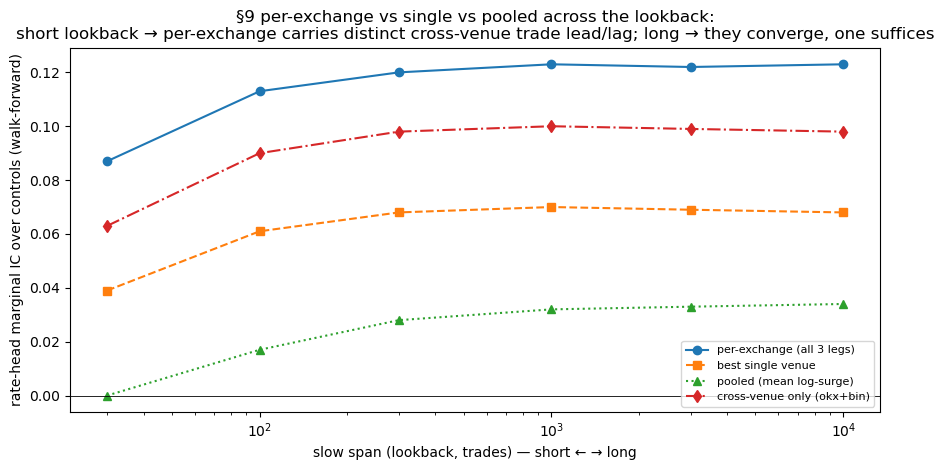

In [12]:
# Plot the per-exchange vs single vs pooled curves across the lookback sweep — the §9 cross-over picture.
xs = [r["slow_span"] for r in look_rows]
per = [r["per_exchange"] for r in look_rows]
sin = [float(r["best_single"].split()[0]) for r in look_rows]
poo = [r["pooled"] for r in look_rows]
crs = [r["cross_venue_only"] for r in look_rows]
fig, ax = plt.subplots(figsize=(9, 4.8))
ax.plot(xs, per, "o-", label="per-exchange (all 3 legs)", color="C0")
ax.plot(xs, sin, "s--", label="best single venue", color="C1")
ax.plot(xs, poo, "^:", label="pooled (mean log-surge)", color="C2")
ax.plot(xs, crs, "d-.", label="cross-venue only (okx+bin)", color="C3")
ax.set_xscale("log"); ax.axhline(0, color="k", lw=0.6)
ax.set_xlabel("slow span (lookback, trades) — short ← → long"); ax.set_ylabel("rate-head marginal IC over controls (walk-forward)")
ax.set_title("§9 per-exchange vs single vs pooled across the lookback:\nshort lookback → per-exchange carries distinct cross-venue trade lead/lag; long → they converge, one suffices")
ax.legend(fontsize=8); fig.tight_layout(); plt.show()

**Conclusion — read the table and curves above.** On this block the §9 picture is **per-exchange wins at
every lookback** — it does **not** show the convergence the template's gap feature does. The per-exchange
set (all three legs) climbs from **0.087** (slow=30) to **~0.123** (slow ≥ 1000) and stays there, always far
above the **best single venue** (always **bin**, only **0.039 → 0.068**), so the venues keep contributing
distinct information rather than collapsing to one. **Pooling** (mean log-surge) is consistently the
*weakest* (**−0.00 → 0.034**) — for this feature, averaging the venues' log-surges blurs the cross-venue
structure rather than helping, so per-exchange is the clear choice over pooled. The **cross-venue-only**
curve (okx+bin, no byb) sits **above 0 at every lookback** (**0.063 → 0.098**), so another venue's trade
tempo genuinely leads byb's move-count over and above byb's own rate — the cross-venue legs carry real
marginal value, and byb's own leg is not doing all the work (per-exchange 0.123 vs cross-venue-only 0.098 at
the longest lookback: byb adds a little on top, the rest is the cross-venue lead). The honest verdict read
straight off these numbers: **keep all three venues per-exchange at every lookback** — the cross-venue
trade-tempo lead/lag here is persistent, not a short-lookback-only effect, and pooling is a net loss.

## 10. The verdict, and what it takes to ship

**Keep the per-venue family — feed every venue's *signed* log-surge to the rate head — but label each leg
for what it is:**
- **Rate head (intensity):** `trade_rate_surge` is the natural input — a fast trade-rate over a slow one;
  the surge ratio predicts byb's move-count (§6/§7). Sweep the (fast, slow) family **per venue** and let the
  data pick (§6 heat-maps); the **§6 conditional-IC** re-score (`partial-IC(cell | chosen)` + the walk-forward
  joint-vs-solo OOS) then asks whether a **second** span adds over the pick — on this block it does not (the
  most-orthogonal alt is a diluted copy, OOS gain ≈ 0), so **one span per head per venue suffices**. Keep all
  three venues per-exchange at **every** lookback (§9) — the cross-venue trade-tempo lead/lag is persistent
  here, **not** a short-lookback-only effect that converges away (§9: per-exchange ~0.123 vs best single
  ~0.068 even at the longest lookback, slow=10000; pooling is a net loss at −0.00–0.034).
- **Price head (direction):** ≈0 — don't feed it expecting direction; it's an intensity feature.
- **Feature form:** `log(trade_rate_surge)` per venue, robust-z, clip ±4 (§8). **No yardstick division** —
  it's already a dimensionless ratio (and so `STRAT_VAR = None`: it shares no denominator with either target).

**The control verdict — TRADE rate vs MOVE rate (the headline, and the contrast with `mid_rate_surge`).**
`trade_rate_surge` is `FEATURE_KIND="control"` — a trade-tempo regime descriptor — but the key contrast:
`mid_rate_surge`'s byb leg *was* `rate_momentum` rebuilt (byb's mid-update rate **is** `λ_ev`), so it was
forced to a circular standalone read and added ≈0 marginal. Here the feature counts **trades**, not
**mid-moves**, and the two genuinely decouple (a trade need not move the mid; the mid moves without a trade)
— so there is **no circular own-leg**, and even the **byb** leg is judged on its **marginal** over the
move-rate controls — an honest test of whether trade tempo carries intensity the move-rate regime misses.
**On this block the thesis holds:** byb's own trade-rate surge adds **+0.052** marginal over the move-rate
controls (not ≈0, despite a high **0.358** |IC| overlap with `rate_momentum`) — trade tempo *does* carry
intensity the move-rate regime misses. The **okx** (+0.051) and **bin** (+0.084) cross-venue legs add on
top; **jointly +0.090**, positive in **5/5** OOS folds (CI **[0.085, 0.094]**) — so another venue's trade
tempo genuinely **leads** byb's move-count. §9 confirms the per-exchange set beats the best single venue
(~0.123 vs ~0.068) at **every** lookback, so keep all three legs per-exchange. Always quote the **§6
marginal**, never a raw IC. **Compared to `mid_rate_surge`:** the comparison this notebook exists to
make is whether the **trade** rate carries anything the **move**-rate surge does not — answered **yes** here,
since the byb-leg marginal is **+0.052**, *not* forced to ≈0 the way `mid_rate_surge`'s circular byb leg was.

**The echo verdict — real prediction, not a contemporaneous echo.** A raw δ=0 IC can be re-reporting the move
already underway at the anchor, so the honest "is this prediction?" number is the **echo-netted (partial)
forward IC** — the feature's correlation with the forward outcome controlling for the **trailing**
`[anchor−100 ms, anchor]` move. This bites hardest on the **byb** own-trade leg, whose trades co-occur with
its moves: if its raw IC collapses once the trailing move is partialled out, it was mostly echoing the burst
already underway, and the **netted** number is the one to cite. The **cross-venue** okx/bin legs do **not**
need coarsening — the recording *is* production timing, so a freshness lead is genuine, exploitable edge, not
an artifact (do not throw it away by matching the foreign feed to byb's cadence). So report the **echo-netted**
forward IC alongside the §6 marginal, and read a near-zero netted IC beside a large backward IC as the one
true non-signal (all echo, no prediction).

**To ship:**
- [ ] the streaming (constant-work-per-trade) builder, per venue, matching this analysis version (§4, done)
- [ ] the §4 parity check and tests, passing **bit-exact for every per-venue leg**
- [ ] the §6 marginal-over-`rate_momentum` recorded **per leg** (byb included), with the trade-rate-vs-move-rate call made
- [ ] the echo-netted (partial) forward IC recorded — the **netted** number cited (raw vs backward vs echo-netted), the byb own-trade leg above all
- [ ] the §9 per-exchange-vs-single cross-over recorded (where per-exchange stops paying)
- [ ] the §6 conditional-IC second-span re-score recorded per head/venue — whether a second time-scale adds OOS (joint-vs-solo gain over the ~0.01 floor) or one span suffices
- [ ] the chosen rate-head time-scale per venue written down, with the yardstick span
- [ ] the data quirks handled (bad zero-price prints; one trade event per timestamp; same dt for all venues)